# **TEL351: Seminario de Telemática**
## **Problema 1: Análisis de Desinformación en Redes Sociales en las Elecciones Presidenciales**

### Pedro Arce

## **Introducción:**

En el contexto de unas elecciones presidenciales, las redes sociales operan como principal canal de difusión, debate y propaganda. Junto con información legítima, también circulan noticias falsas, campañas coordinadas de desinformación y actividad de cuentas automatizadas (bots) que pueden distorsionar la conversación pública. El siguiente trabajo propone un abordaje reproducible, desde la recolección hasta el análisis, para estudiar cómo se propagan los rumores en comparación con publicaciones verificadas, identificar a los actores que los amplifican, caracterizar comunidades y narrativas asociadas, y observar patrones temporales y geográficos de difusión. La motivación es doble: comprender los mecanismos de propagación y aportar herramientas prácticas para su monitoreo durante procesos electorales.

### **Objetivos:**

El objetivo principal de este análisis es identificar y caracterizar las comunidades que se forman en torno a la desinformación durante el periodo electoral. Para lograrlo, se plantean los siguientes objetivos específicos:

1.   **Construir un grafo de interacciones** que modele las relaciones entre candidatos, usuarios y temas de fake news.
2.   **Aplicar algoritmos de detección de comunidades** para identificar los principales grupos de discusión y difusión de narrativas.
3. **Analizar el contenido textual** de cada comunidad para extraer los temas y narrativas dominantes, identificando posibles sesgos.
4. **Comparar la actividad** de usuarios humanos frente a cuentas sospechosas de ser bots para entender su rol en la viralización de contenido.
5. **Visualizar los resultados** mediante grafos y nubes de palabras para interpretar los patrones de propagación de la desinformación.

## **Parte 1: Seguimiento de la difusión de noticias falsas**

In [ ]:
###Instalacion de librerias necesarias:

!pip install pandas matplotlib wordcloud transformers torch seaborn
!pip3 install emoji==0.6.0
!pip install nest_asyncio
!pip install asyncio
!pip install playwright
!playwright install
!pip install tldextract
!pip install jinja2
!pip install networkx
!pip install pyvis
!pip install plotly

##python -m playwright codegen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=14184788a1afdaa77570d8f9638bce954d4e115d2b39dd9880fca8ae3a0b57c7
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 MB 19.9 MB/s eta 0:00:00
173.7 MiB [] 0% 0.0s173.7 MiB [] 0% 25.4s173.7 MiB [] 0% 13.7s173.7 MiB [] 0% 10.4s173.7 MiB [] 0% 6.7s173.7 MiB [] 1% 5.7s173.7 MiB [] 1% 5.2s173.7 MiB [] 2% 4.6s173.7 MiB [] 3% 3.9s173.7 MiB [] 3% 3.6s173.7 MiB [] 4% 3.6s173.7 MiB [] 4% 3.5s173.7 MiB [] 5% 3.4s173.7 MiB [] 5% 3.7s173.7 MiB [] 6% 3.6s173.7 MiB [] 6% 3.7s173.7 MiB [] 7% 3.5s173.7 MiB [] 7% 3.4s173.7 MiB [] 8% 3.3s173.7 MiB [] 9% 3.4s173.7 MiB [] 10% 3.3s173.7 MiB [] 11% 3.1s173.7 MiB [] 12% 3.0s173.7 MiB [] 13% 2.9s173.7 MiB [] 13% 3.0s173.7 MiB []

### Scraper X/Twitter con Playwright
### - Guarda: election_posts_candidates.csv y tweets_fake_candidates.csv
### - Incluye: cookies, concurrencia, comportamiento humano

In [ ]:
import asyncio
from playwright.async_api import async_playwright
from playwright.async_api import TimeoutError as PWTimeoutError
import json
import pandas as pd
import random
import time
import nest_asyncio
import re
import html
import unicodedata
from urllib.parse import urlparse, quote_plus
import csv
from datetime import datetime, timedelta

# Para Colab/Notebook
nest_asyncio.apply()

# =========================
# Config
# =========================
# 1) Keywords de elecciones (recall general)
ELECTION_KEYWORDS = [
    "elecciones", "segunda vuelta", "debate presidencial", "candidato",
    "conteo de votos", "servel", "tribunal electoral", "escrutinio",
    "actas", "urna", "apoderados", "voto nulo", "mesas", "primera vuelta",
]

# 2) Léxico explícito de “fake” (búsqueda + regex)
FAKE_TERMS = [
    "fraude electoral", "fraude", "pucherazo", "apagón informático",
    "actas falsas", "actas adulteradas", "actas alteradas",
    "urnas rellenas", "urnas infladas", "urnas quemadas", "robo de urnas",
    "manipulación del conteo", "conteo manipulado", "cómputo manipulado",
    "voto fantasma", "padrón inflado", "acarreo de votantes", "compra de votos",
]

# 3) Patrones regex derivados (amplios)
FAKE_PATTERNS = [
    r"\bfraude(\s+electoral)?\b",
    r"\bpucherazo\b",
    r"\bapag[oó]n\s+inform[aá]tico\b",
    r"\bactas?\s+(falsas|adulteradas|alteradas)\b",
    r"\burnas?\s+(rellenas|infladas|quemadas|robadas)\b",
    r"\bmanipulaci[oó]n\s+(del\s+)?(conteo|c[oó]mputo)\b",
    r"\bconteo\s+(manipulado|paralelo)\b",
    r"\bc[oó]mputo\s+(paralelo|manipulado)\b",
    r"\bvotos?\s+fantasma(s)?\b",
    r"\bpadr[oó]n\s+(inflado|manipulado)\b",
    r"\bacarreo(\s+de\s+votantes)?\b",
    r"\bcompra\s+de\s+votos\b",
]
FAKE_REGEX = re.compile("|".join(FAKE_PATTERNS), re.IGNORECASE)

# 4) “Debunk” (señales de desmentido)
DEBUNK_PATTERNS = [
    r"\b(falso|bulo|desmentid[oa]|no es cierto|desinformaci[oó]n)\b",
    r"\b(verificamos|fact[-\s]?check|comprobamos|es mentira)\b",
]
DEBUNK_REGEX = re.compile("|".join(DEBUNK_PATTERNS), re.IGNORECASE)

# 5) Búsqueda dual (más recall)
SEARCH_SOURCES = ["top", "live"]   # usa ["top"] o ["live"] si prefieres una sola

# 6) Filtrado por difusión
MIN_RETWEETS = 20
MIN_REPLIES  = 10

# 7) Límites de scraping
MAX_TWEETS            = 40
FAST_STAGE_REPLIES    = 60
DEEP_STAGE_REPLIES    = 250
EARLY_STOP_NO_HIT_SCROLLS = 6
CONCURRENCY = 4

# 8) Fechas (opcional)
SINCE_DAYS = None        # por ejemplo: 10
UNTIL_DAYS = None        # por ejemplo: 0

# 9) Flags de recolección
APPLY_KEYWORDS_ON_REPLIES = False    # False: FAKE/DEBUNK sobre todas las replies/quotes
SCAN_QUOTES = True                    # escanear pestaña "Citas"
INCLUDE_ONLY_LINK_OR_KEYWORD = True  # True: solo guardamos si (tiene link) o (match KW)

# 10) Lista negra de dominios (opcional)
BAD_DOMAINS = {
    # "midominio-dudoso.com",
}

UNAVAILABLE_TEXTS = [
    "Este contenido no está disponible", "Esta cuenta no existe", "Esta cuenta está suspendida",
    "La publicación no está disponible", "No existe", "This post is unavailable",
    "This account doesn’t exist", "This account is suspended", "Something went wrong",
    "This page doesn’t exist",
]

# =========================
# Utilidades
# =========================
def clean_text(s: str) -> str:
    if not s:
        return ""
    s = html.unescape(s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"[\u200B-\u200F\uFEFF]", "", s)  # ZWSP/ZWNJ/ZWJ/BOM
    s = s.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_urls_from_text(text: str):
    return re.findall(r'https?://\S+', text or "")

def extract_domain(u: str) -> str:
    try:
        return urlparse(u).netloc.lower()
    except:
        return ""

async def load_cookies(context, cookies_path="cookies.json"):
    try:
        with open(cookies_path, "r") as f:
            cookies = json.load(f)
        for cookie in cookies:
            if "sameSite" in cookie and cookie["sameSite"] not in ["Strict", "Lax", "None"]:
                cookie["sameSite"] = "Lax"
        await context.add_cookies(cookies)
        print("Cookies cargadas exitosamente.")
    except FileNotFoundError:
        print(f"Archivo {cookies_path} no encontrado. Procediendo sin cookies.")
    except Exception as e:
        print(f"Error al cargar las cookies: {e}")

async def save_cookies(context, cookies_path="cookies.json"):
    try:
        cookies = await context.cookies()
        with open(cookies_path, "w") as f:
            json.dump(cookies, f)
        print(f"Cookies guardadas en {cookies_path}.")
    except Exception as e:
        print(f"Error al guardar las cookies: {e}")

def _date_filter_clause():
    if SINCE_DAYS is None:
        return ""
    until_days = 0 if UNTIL_DAYS is None else UNTIL_DAYS
    today = datetime.utcnow().date()
    since = today - timedelta(days=SINCE_DAYS)
    until = today - timedelta(days=until_days)
    return f" since:{since.isoformat()} until:{until.isoformat()}"

def build_search_queries():
    # A) consultas centradas en fraude
    fake_quoted = [f'"{t}"' if " " in t else t for t in FAKE_TERMS]
    q_fake = " OR ".join(fake_quoted)

    # B) consultas centradas en elecciones
    election_quoted = [f'"{t}"' if " " in t else t for t in ELECTION_KEYWORDS]
    q_elec = " OR ".join(election_quoted)

    filters = []
    if MIN_RETWEETS > 0: filters.append(f"min_retweets:{MIN_RETWEETS}")
    if MIN_REPLIES  > 0: filters.append(f"min_replies:{MIN_REPLIES}")
    filters.append("lang:es")
    date_clause = _date_filter_clause()
    tail = " " + " ".join(filters) + date_clause

    return [
        f"({q_fake}){tail}",     # “fake-first”
        f"({q_elec}){tail}",     # “election-first”
    ]

def build_search_urls():
    urls = []
    for q in build_search_queries():
        for src in SEARCH_SOURCES:
            urls.append(f"https://x.com/search?q={quote_plus(q)}&src=typed_query&f={src}")
    return urls

def matches_keywords(text: str) -> bool:
    if not text:
        return False
    KW = re.compile("|".join([re.escape(k) for k in (ELECTION_KEYWORDS + FAKE_TERMS)]), re.IGNORECASE)
    return bool(KW.search(text))

def text_has_fake_signals(text: str) -> (bool, str):
    if not text:
        return False, ""
    if FAKE_REGEX.search(text):
        return True, "fake_regex"
    for u in extract_urls_from_text(text):
        dom = extract_domain(u)
        for bd in BAD_DOMAINS:
            if bd in dom:
                return True, f"bad_domain:{bd}"
    return False, ""

def text_has_debunk_signals(text: str) -> bool:
    if not text:
        return False
    return bool(DEBUNK_REGEX.search(text))

def bot_score_from_handle_and_name(handle: str, display_name: str) -> float:
    score = 0.0
    handle = handle or ""
    display_name = display_name or ""
    if re.search(r"\d{5,}", handle): score += 0.4
    if len(display_name) > 20 and re.search(r"\d", display_name): score += 0.2
    if re.search(r"\d+$", handle): score += 0.2
    if len(re.findall(r"[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s]", display_name)) > 3: score += 0.2
    return min(score, 1.0)

async def page_looks_unavailable(page) -> bool:
    try:
        body_txt = (await page.locator("body").inner_text()).strip().lower()
    except:
        return True
    return any(s.lower() in body_txt for s in UNAVAILABLE_TEXTS)

async def safe_goto(page, url, retries=3):
    for i in range(retries):
        try:
            resp = await page.goto(url, wait_until="domcontentloaded", timeout=20000)
            if resp and resp.status >= 400:
                await page.wait_for_timeout(1200 + 400*i)
                await page.reload(wait_until="domcontentloaded")
            if await page_looks_unavailable(page):
                return False
            return True
        except PWTimeoutError:
            if i == retries - 1:
                return False
            await page.wait_for_timeout(1200 + 600*i)
    return False

# ---------- FIX & robust helpers (evita NameError) ----------
def _parse_first_int(s: str):
    """Extrae el primer entero de un texto tipo '12 retuits' o '1.2 K likes' (sin K/M)."""
    if not s:
        return None
    m = re.search(r"(\d[\d\.,]*)", s)
    if not m:
        return None
    return int(m.group(1).replace(".", "").replace(",", ""))

async def robust_get_action_count(article, action: str):
    """
    Intenta leer el número de replies/retuits/likes buscando:
      1) aria-label del botón
      2) contenedor dinámico del contador (fallback)
    """
    sel_candidates = []
    if action == "reply":
        sel_candidates = ['button[data-testid="reply"]', 'div[data-testid="reply"]']
    elif action == "retweet":
        sel_candidates = [
            'button[data-testid="retweet"]', 'div[data-testid="retweet"]',
            'button[data-testid="repost"]',  'div[data-testid="repost"]',
        ]
    elif action == "like":
        sel_candidates = ['button[data-testid="like"]', 'div[data-testid="like"]']

    # 1) aria-label
    for sel in sel_candidates:
        try:
            el = await article.query_selector(sel)
            if el:
                lab = await el.get_attribute("aria-label")
                num = _parse_first_int(lab or "")
                if num is not None:
                    return num
        except:
            pass

    # 2) contenedor dinámico
    for sel in sel_candidates:
        try:
            el = await article.query_selector(sel)
            if not el:
                continue
            num_txt = await el.evaluate('''(e) => {
                let n = e;
                for (let i = 0; i < 6 && n; i++) {
                    const t = n.querySelector('[data-testid="app-text-transition-container"]');
                    if (t && t.innerText) return t.innerText;
                    n = n.parentElement;
                }
                return "";
            }''')
            num = _parse_first_int(num_txt or "")
            if num is not None:
                return num
        except:
            pass
    return None

async def robust_get_numbers_from_article(article):
    """Devuelve (replies, retweets, likes) con fallback 0 si no se encuentra."""
    try:
        replies  = await robust_get_action_count(article, "reply")
        retweets = await robust_get_action_count(article, "retweet")
        likes    = await robust_get_action_count(article, "like")
    except Exception:
        replies = retweets = likes = None
    return (replies or 0, retweets or 0, likes or 0)
# -----------------------------------------------------------

async def extract_time_from_article(article):
    try:
        t = await article.query_selector('time[datetime]')
        if t:
            return await t.get_attribute("datetime")  # ISO 8601 UTC
    except:
        pass
    return ""

async def extract_links_from_article(article):
    """
    Devuelve (urls, expanded_urls, domains)
    - Busca anchors con data-expanded-url (si existe) y href http(s)
    - Complementa con urls detectadas en texto
    """
    urls = set()
    expanded = set()
    domains = set()
    try:
        anchors = await article.query_selector_all('a[href^="http"]')
        for a in anchors:
            href = await a.get_attribute("href")
            if href and href.startswith("http"):
                urls.add(href)
            # a veces X expone data-expanded-url con el destino final
            exp = await a.get_attribute("data-expanded-url")
            if exp and exp.startswith("http"):
                expanded.add(exp)
    except:
        pass
    # Si no hay expanded, intenta con título del anchor (a veces muestra el expand)
    if not expanded:
        try:
            anchors = await article.query_selector_all('a[href^="http"]')
            for a in anchors:
                tit = await a.get_attribute("title")
                if tit and tit.startswith("http"):
                    expanded.add(tit)
        except:
            pass
    # Complementar con urls del texto
    try:
        tnode = await article.query_selector('[data-testid="tweetText"]')
        if tnode:
            txt = await tnode.inner_text()
            for u in extract_urls_from_text(txt):
                urls.add(u)
    except:
        pass

    # Domains
    for u in (expanded or urls):
        d = extract_domain(u)
        if d:
            domains.add(d)

    return list(urls), list(expanded), list(domains)

# =========================
# 1) Buscar enlaces candidatos (multi consultas)
# =========================
async def collect_candidates(context, max_tweets):
    seen_ids = set()
    links = []

    for url in build_search_urls():
        print(f"Buscando en: {url}")
        page = await context.new_page()
        await page.goto(url)
        scroll_attempts = 0
        max_scroll_attempts = 28
        while len(links) < max_tweets and scroll_attempts < max_scroll_attempts:
            tweet_elements = await page.query_selector_all('a[role="link"][href*="/status/"]')
            for el in tweet_elements:
                href = await el.get_attribute("href")
                if not href or any(x in href for x in ["/photo", "/analytics", "/video", "/media_tags"]):
                    continue
                parts = [s for s in urlparse(href).path.split("/") if s]
                if len(parts) >= 2 and parts[-2] == "status":
                    tid = parts[-1]
                    if tid not in seen_ids:
                        seen_ids.add(tid)
                        links.append(f"https://x.com{href}")
                        if len(links) >= max_tweets:
                            break
            await page.evaluate("window.scrollBy(0, window.innerHeight);")
            await page.wait_for_timeout(random.randint(1500, 3000))
            scroll_attempts += 1
            if scroll_attempts % 5 == 0:
                print("Esperando para simular comportamiento humano…")
                time.sleep(random.randint(3, 7))
        await page.close()
        if len(links) >= max_tweets:
            break
    return links

# =========================
# 2) Escaneo de hilo (tweet + replies + quotes)
# =========================
async def open_thread_and_scan(context, link):
    page = await context.new_page()
    print(f"Abrir hilo: {link}")
    ok = await safe_goto(page, link, retries=3)
    if not ok:
        await page.close()
        return None, [], []

    try:
        await page.wait_for_selector('main [data-testid="primaryColumn"]', timeout=12000)
    except PWTimeoutError:
        pass

    # Artículos
    articles = []
    try:
        await page.wait_for_selector("article", timeout=10000)
        articles = await page.query_selector_all("article")
    except PWTimeoutError:
        for _ in range(3):
            await page.wait_for_timeout(1500)
            articles = await page.query_selector_all("article")
            if articles:
                break
    if not articles:
        await page.close()
        return None, [], []

    # Tweet principal
    main = articles[0]
    tweet_text = author_handle = author_name = ""
    tweet_id = ""
    tweet_time = ""
    try:
        txt_el = await main.query_selector('[data-testid="tweetText"]')
        if txt_el:
            tweet_text = clean_text(await txt_el.inner_text())
    except:
        pass
    try:
        handle_el = await main.query_selector('a[href^="/"] span:has-text("@")')
        if handle_el:
            author_handle = clean_text((await handle_el.inner_text()).strip().lstrip("@"))
    except:
        pass
    try:
        name_el = await main.query_selector('div[dir="ltr"] span')
        if name_el:
            author_name = clean_text((await name_el.inner_text()).strip())
    except:
        pass
    try:
        link_main = await main.query_selector('a:has(time[datetime])')
        if link_main:
            href = await link_main.get_attribute("href")
            if href:
                p = [s for s in urlparse(href).path.split("/") if s]
                if len(p) >= 3 and p[-2] == "status":
                    tweet_id = p[-1]
    except:
        tweet_id = ""
    tweet_time = await extract_time_from_article(main)
    replies_count, retweets_count, likes_count = await robust_get_numbers_from_article(main)
    urls_main, expanded_main, domains_main = await extract_links_from_article(main)

    # Señales tweet
    is_fake_tweet, reason_tweet = text_has_fake_signals(tweet_text)
    is_debunk_tweet = text_has_debunk_signals(tweet_text)
    has_kw_tweet = matches_keywords(tweet_text)
    has_link_tweet = bool(urls_main or expanded_main)

    def text_passes_collection(text: str) -> bool:
        if not INCLUDE_ONLY_LINK_OR_KEYWORD:
            return True
        return matches_keywords(text)

    async def scan_container(container_page, label, limit_replies, max_scrolls):
        results = []
        seen_ids = set()
        seen_keys = set()
        scanned = 0
        scrolls = 0
        while scanned < limit_replies and scrolls < max_scrolls:
            arts = await container_page.query_selector_all("article")
            for a in arts[1:]:
                if scanned >= limit_replies:
                    break
                # id, time
                rid = None
                rtime = ""
                try:
                    link_el = await a.query_selector('a:has(time[datetime])')
                    if link_el:
                        href = await link_el.get_attribute("href")
                        if href:
                            p = [s for s in urlparse(href).path.split("/") if s]
                            if len(p) >= 3 and p[-2] == "status":
                                rid = p[-1]
                    rtime = await extract_time_from_article(a)
                except:
                    rid = None

                # text
                try:
                    tnode = await a.query_selector('[data-testid="tweetText"]')
                    if not tnode:
                        continue
                    rtext = clean_text(await tnode.inner_text())
                except:
                    continue

                # anchors / links
                r_urls, r_expanded, r_domains = await extract_links_from_article(a)
                r_has_link = bool(r_urls or r_expanded)

                # filtro de colección (solo keyword o link)
                if INCLUDE_ONLY_LINK_OR_KEYWORD and not (matches_keywords(rtext) or r_has_link):
                    scanned += 1
                    continue

                # autor
                try:
                    r_handle_el = await a.query_selector('a[href^="/"] span:has-text("@")')
                    r_handle = clean_text((await r_handle_el.inner_text()).strip().lstrip("@")) if r_handle_el else ""
                except:
                    r_handle = ""
                try:
                    r_name_el = await a.query_selector('div[dir="ltr"] span')
                    r_name = clean_text((await r_name_el.inner_text()).strip()) if r_name_el else ""
                except:
                    r_name = ""

                # dedup
                if rid:
                    if rid in seen_ids:
                        scanned += 1
                        continue
                    seen_ids.add(rid)
                else:
                    key = (r_handle, rtext)
                    if key in seen_keys:
                        scanned += 1
                        continue
                    seen_keys.add(key)

                # Señales
                is_fake_reply, reason_reply = text_has_fake_signals(rtext)
                is_debunk_reply = text_has_debunk_signals(rtext)

                results.append({
                    "container": label,
                    "reply_id": rid or "",
                    "reply_time": rtime,
                    "reply_author_handle": r_handle,
                    "reply_author_name": r_name,
                    "reply_text": rtext,
                    "reply_bot_score": bot_score_from_handle_and_name(r_handle, r_name),
                    "fake_reason": reason_reply if is_fake_reply else "",
                    "is_fake": is_fake_reply,
                    "is_debunk": is_debunk_reply,
                    "has_link": r_has_link,
                    "urls": ";".join(r_urls or []),
                    "expanded_urls": ";".join(r_expanded or []),
                    "domains": ";".join(r_domains or []),
                })
                scanned += 1

            await container_page.evaluate("window.scrollBy(0, window.innerHeight);")
            await container_page.wait_for_timeout(random.randint(1000, 2200))
            scrolls += 1
            if scrolls % 6 == 0:
                time.sleep(random.randint(3, 6))
            if scrolls >= EARLY_STOP_NO_HIT_SCROLLS and scanned >= FAST_STAGE_REPLIES:
                break
        return results

    # Replies (fase rápida + profunda)
    replies = await scan_container(page, "replies", FAST_STAGE_REPLIES, EARLY_STOP_NO_HIT_SCROLLS)
    if len(replies) >= 1:
        replies += await scan_container(page, "replies", DEEP_STAGE_REPLIES, 30)

    # Quotes (opcional)
    quotes = []
    if SCAN_QUOTES:
        try:
            quotes_tab = await page.query_selector('a[role="tab"][href$="/quotes"]')
            if quotes_tab:
                await quotes_tab.click()
                await page.wait_for_timeout(1200)
                quotes = await scan_container(page, "quotes", FAST_STAGE_REPLIES, EARLY_STOP_NO_HIT_SCROLLS)
                if len(quotes) >= 1:
                    quotes += await scan_container(page, "quotes", DEEP_STAGE_REPLIES, 30)
        except:
            pass

    await page.close()

    tweet_meta = {
        "tweet_id": tweet_id,
        "tweet_time": tweet_time,
        "tweet_text": tweet_text,
        "tweet_author_handle": author_handle,
        "tweet_author_name": author_name,
        "replies_count": replies_count,
        "retweets_count": retweets_count,
        "likes_count": likes_count,
        "urls": ";".join(urls_main or []),
        "expanded_urls": ";".join(expanded_main or []),
        "domains": ";".join(domains_main or []),
        "has_link": has_link_tweet,
        "has_kw": has_kw_tweet,
        "is_fake": is_fake_tweet,
        "fake_reason": reason_tweet if is_fake_tweet else "",
        "is_debunk": is_debunk_tweet,
    }
    return tweet_meta, replies, quotes

# =========================
# 3) Pipeline con concurrencia
# =========================
async def main():
    print("Recolectando candidatos con alta difusión…")
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(timezone_id="America/Santiago", locale="es-CL")
        await load_cookies(context)

        links = await collect_candidates(context, MAX_TWEETS)
        print(f"Candidatos: {len(links)}")

        sem = asyncio.Semaphore(CONCURRENCY)
        results = []

        async def worker(link):
            async with sem:
                print(f"Procesando hilo: {link}")
                try:
                    meta, replies, quotes = await open_thread_and_scan(context, link)
                    results.append((link, meta, replies, quotes))
                except Exception as e:
                    print(f"   → Error en hilo {link}: {e}")
                if random.random() < 0.35:
                    time.sleep(random.randint(2, 5))

        await asyncio.gather(*(worker(l) for l in links))

        await save_cookies(context)
        await browser.close()

    # Construcción de filas
    rows_all = []   # todo lo relevante (keyword o link)
    rows_fake = []  # solo fake candidates (como antes)

    for link, meta, replies, quotes in results:
        if not meta:
            continue

        # Tweet principal → dataset “all” si (keyword o link)
        if (not INCLUDE_ONLY_LINK_OR_KEYWORD) or meta.get("has_kw") or meta.get("has_link"):
            label = "fake_candidate" if meta.get("is_fake") else ("debunk_candidate" if meta.get("is_debunk") else "unknown")
            rows_all.append({
                "url": link,
                "where_matched": "tweet",
                "container": "tweet",
                "tweet_id": meta["tweet_id"],
                "tweet_time": meta["tweet_time"],
                "tweet_author_handle": meta["tweet_author_handle"],
                "tweet_author_name": meta["tweet_author_name"],
                "tweet_text": clean_text(meta["tweet_text"]),
                "retweets": meta["retweets_count"],
                "replies": meta["replies_count"],
                "likes": meta["likes_count"],
                "reply_id": "",
                "reply_time": "",
                "reply_author_handle": "",
                "reply_author_name": "",
                "reply_text": "",
                "reply_bot_score": "",
                "has_link": meta["has_link"],
                "urls": meta["urls"],
                "expanded_urls": meta["expanded_urls"],
                "domains": meta["domains"],
                "label": label,
                "fake_reason": meta.get("fake_reason",""),
            })

        # Siempre: si el tweet es fake → dataset “fake”
        if meta.get("is_fake"):
            rows_fake.append({
                "url": link,
                "tweet_id": meta["tweet_id"],
                "reply_id": "",
                "where_matched": "tweet",
                "container": "tweet",
                "tweet_text": clean_text(meta["tweet_text"]),
                "tweet_author_handle": clean_text(meta["tweet_author_handle"]),
                "tweet_author_name": clean_text(meta["tweet_author_name"]),
                "retweets": meta["retweets_count"],
                "replies": meta["replies_count"],
                "likes": meta["likes_count"],
                "reply_author_handle": "",
                "reply_author_name": "",
                "reply_text": "",
                "reply_bot_score": "",
                "fake_reason": meta.get("fake_reason",""),
            })

        # Replies y Quotes → dataset “all” si (keyword o link)
        for bucket, where in [(replies, "reply"), (quotes, "quote")]:
            for r in bucket:
                if INCLUDE_ONLY_LINK_OR_KEYWORD and not (matches_keywords(r["reply_text"]) or r["has_link"]):
                    continue
                label = "fake_candidate" if r["is_fake"] else ("debunk_candidate" if r["is_debunk"] else "unknown")
                rows_all.append({
                    "url": link,
                    "where_matched": where,
                    "container": r.get("container", where),
                    "tweet_id": meta["tweet_id"],
                    "tweet_time": meta["tweet_time"],
                    "tweet_author_handle": meta["tweet_author_handle"],
                    "tweet_author_name": meta["tweet_author_name"],
                    "tweet_text": clean_text(meta["tweet_text"]),
                    "retweets": meta["retweets_count"],
                    "replies": meta["replies_count"],
                    "likes": meta["likes_count"],
                    "reply_id": r.get("reply_id",""),
                    "reply_time": r.get("reply_time",""),
                    "reply_author_handle": r["reply_author_handle"],
                    "reply_author_name": r["reply_author_name"],
                    "reply_text": r["reply_text"],
                    "reply_bot_score": r["reply_bot_score"],
                    "has_link": r["has_link"],
                    "urls": r["urls"],
                    "expanded_urls": r["expanded_urls"],
                    "domains": r["domains"],
                    "label": label,
                    "fake_reason": r.get("fake_reason",""),
                })
                if r["is_fake"]:
                    rows_fake.append({
                        "url": link,
                        "tweet_id": meta["tweet_id"],
                        "reply_id": r.get("reply_id",""),
                        "where_matched": where,
                        "container": r.get("container", where),
                        "tweet_text": clean_text(meta["tweet_text"]),
                        "tweet_author_handle": clean_text(meta["tweet_author_handle"]),
                        "tweet_author_name": clean_text(meta["tweet_author_name"]),
                        "retweets": meta["retweets_count"],
                        "replies": meta["replies_count"],
                        "likes": meta["likes_count"],
                        "reply_author_handle": r["reply_author_handle"],
                        "reply_author_name": r["reply_author_name"],
                        "reply_text": r["reply_text"],
                        "reply_bot_score": r["reply_bot_score"],
                        "fake_reason": r.get("fake_reason",""),
                    })

    # ---- Export ----
    def export_csv(df, path):
        # limpieza mínima y dedup fuerte
        for c in ["tweet_text","tweet_author_handle","tweet_author_name",
                  "reply_author_handle","reply_author_name","reply_text","fake_reason"]:
            if c in df.columns:
                df[c] = df[c].astype(str).map(clean_text)
        subset_keys = [c for c in ["url","where_matched","container","tweet_id","reply_id","reply_author_handle","reply_text"] if c in df.columns]
        if subset_keys:
            df = df.drop_duplicates(subset=subset_keys)
        df.to_csv(
            path,
            index=False,
            encoding="utf-8-sig",
            quoting=csv.QUOTE_ALL,
            lineterminator="\n",   # <= corrige el error de line_terminator
        )
        return df

    if rows_all:
        df_all = pd.DataFrame(rows_all)
        df_all = export_csv(df_all, "election_posts_candidates.csv")
        print("Guardado en 'election_posts_candidates.csv' (filas únicas:", len(df_all), ")")
    else:
        print("No hubo publicaciones relevantes para 'election_posts_candidates.csv'.")

    if rows_fake:
        df_fake = pd.DataFrame(rows_fake)
        df_fake = export_csv(df_fake, "tweets_fake_candidates.csv")
        print("Guardado en 'tweets_fake_candidates.csv' (filas únicas:", len(df_fake), ")")
    else:
        print("No hubo casos 'fake' bajo las heurísticas actuales.")

# Ejecutar
asyncio.run(main())



Recolectando candidatos con alta difusión…
Cookies cargadas exitosamente.
Buscando en: https://x.com/search?q=%28%22fraude+electoral%22+OR+fraude+OR+pucherazo+OR+%22apag%C3%B3n+inform%C3%A1tico%22+OR+%22actas+falsas%22+OR+%22actas+adulteradas%22+OR+%22actas+alteradas%22+OR+%22urnas+rellenas%22+OR+%22urnas+infladas%22+OR+%22urnas+quemadas%22+OR+%22robo+de+urnas%22+OR+%22manipulaci%C3%B3n+del+conteo%22+OR+%22conteo+manipulado%22+OR+%22c%C3%B3mputo+manipulado%22+OR+%22voto+fantasma%22+OR+%22padr%C3%B3n+inflado%22+OR+%22acarreo+de+votantes%22+OR+%22compra+de+votos%22%29+min_retweets%3A20+min_replies%3A10+lang%3Aes&src=typed_query&f=top
Esperando para simular comportamiento humano…
Esperando para simular comportamiento humano…
Esperando para simular comportamiento humano…
Esperando para simular comportamiento humano…
Esperando para simular comportamiento humano…
Buscando en: https://x.com/search?q=%28%22fraude+electoral%22+OR+fraude+OR+pucherazo+OR+%22apag%C3%B3n+inform%C3%A1tico%22+OR+%22a

### Cascadas de difusión (retuits/quotes/replies/mentions) como grafos

In [ ]:
import pandas as pd, re, networkx as nx, io, zipfile, os

# ------- Config -------
PATH_ALL   = "election_posts_candidates.csv"      # ajusta si hace falta
OUTPUT_DIR = "election_outputs"                   # carpeta común de salidas
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------- Carga y normalización -------
dfa = pd.read_csv(PATH_ALL)
for tcol in ["tweet_time","reply_time"]:
    if tcol in dfa.columns:
        dfa[tcol] = pd.to_datetime(dfa[tcol], errors="coerce", utc=True)
for col in ["tweet_author_handle","tweet_author_name","reply_author_handle",
            "reply_author_name","tweet_text","reply_text","where_matched","container","label"]:
    if col in dfa.columns:
        dfa[col] = dfa[col].astype(str).fillna("").str.strip()

# ------- Reglas de cascada -------
MENTION_RX = re.compile(r'@([A-Za-z0-9_]{1,15})')
def mentions_in(text): return MENTION_RX.findall(text or "")

G = nx.DiGraph()        # grafo agregado
cascades = {}           # cascadas por tweet_id (DiGraph)

for _, r in dfa.iterrows():
    root = (r.get("tweet_author_handle") or "").lower()
    if not root:
        continue
    twid = str(r.get("tweet_id") or "")
    where = (r.get("where_matched") or "").lower()
    reply_user = (r.get("reply_author_handle") or "").lower()
    rtext = r.get("reply_text") or ""

    # Nodo autor del tweet
    if not G.has_node(root):
        G.add_node(root, role="tweet_author")

    # Cascada por tweet_id
    if twid and twid not in cascades:
        cg = nx.DiGraph()
        cg.add_node(root, role="tweet_author",
                    tweet_id=twid,
                    tweet_time=str(r.get("tweet_time") or ""))
        cascades[twid] = cg

    # Aristas root -> reply/quote
    if where in ("reply","quote"):
        if reply_user:
            if not G.has_node(reply_user):
                G.add_node(reply_user, role="participant")
            if not G.has_edge(root, reply_user):
                G.add_edge(root, reply_user, weight=0, types_str="")
            G.edges[root, reply_user]["weight"] += 1
            tlist = [t for t in G.edges[root, reply_user]["types_str"].split(",") if t]
            if where not in tlist:
                tlist.append(where)
            G.edges[root, reply_user]["types_str"] = ",".join(sorted(tlist))

            cg = cascades.get(twid)
            if cg is not None:
                if not cg.has_node(reply_user): cg.add_node(reply_user, role="participant")
                if not cg.has_edge(root, reply_user):
                    cg.add_edge(root, reply_user, weight=0, types_str="")
                cg.edges[root, reply_user]["weight"] += 1
                tlist2 = [t for t in cg.edges[root, reply_user]["types_str"].split(",") if t]
                if where not in tlist2:
                    tlist2.append(where)
                cg.edges[root, reply_user]["types_str"] = ",".join(sorted(tlist2))

        # Menciones: reply_user -> @mencion
        if reply_user and rtext:
            for m in mentions_in(rtext):
                m = m.lower()
                if m in (root, reply_user):
                    continue
                if not G.has_node(m): G.add_node(m, role="mentioned")
                if not G.has_edge(reply_user, m):
                    G.add_edge(reply_user, m, weight=0, types_str="")
                G.edges[reply_user, m]["weight"] += 1
                tlist3 = [t for t in G.edges[reply_user, m]["types_str"].split(",") if t]
                if "mention" not in tlist3:
                    tlist3.append("mention")
                G.edges[reply_user, m]["types_str"] = ",".join(sorted(tlist3))

                cg = cascades.get(twid)
                if cg is not None:
                    if not cg.has_node(m): cg.add_node(m, role="mentioned")
                    if not cg.has_edge(reply_user, m):
                        cg.add_edge(reply_user, m, weight=0, types_str="")
                    cg.edges[reply_user, m]["weight"] += 1
                    tlist4 = [t for t in cg.edges[reply_user, m]["types_str"].split(",") if t]
                    if "mention" not in tlist4:
                        tlist4.append("mention")
                    cg.edges[reply_user, m]["types_str"] = ",".join(sorted(tlist4))

# ------- Exportar a carpeta común -------
gexf_path    = os.path.join(OUTPUT_DIR, "propagation_graph.gexf")
summary_path = os.path.join(OUTPUT_DIR, "cascade_summary.csv")
zip_path     = os.path.join(OUTPUT_DIR, "cascades_gexf.zip")

nx.write_gexf(G, gexf_path)

summary_rows = []
for tid, cg in cascades.items():
    summary_rows.append({
        "tweet_id": tid,
        "nodes": cg.number_of_nodes(),
        "edges": cg.number_of_edges(),
        "density": nx.density(cg) if cg.number_of_nodes() > 1 else 0.0
    })
summary_df = pd.DataFrame(summary_rows).sort_values("edges", ascending=False)
summary_df.to_csv(summary_path, index=False)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for tid, cg in cascades.items():
        buf = io.BytesIO()
        nx.write_gexf(cg, buf)
        zf.writestr(f"cascade_{tid}.gexf", buf.getvalue())

print("OK →", gexf_path, "|", summary_path, "|", zip_path)


OK → election_outputs/propagation_graph.gexf | election_outputs/cascade_summary.csv | election_outputs/cascades_gexf.zip


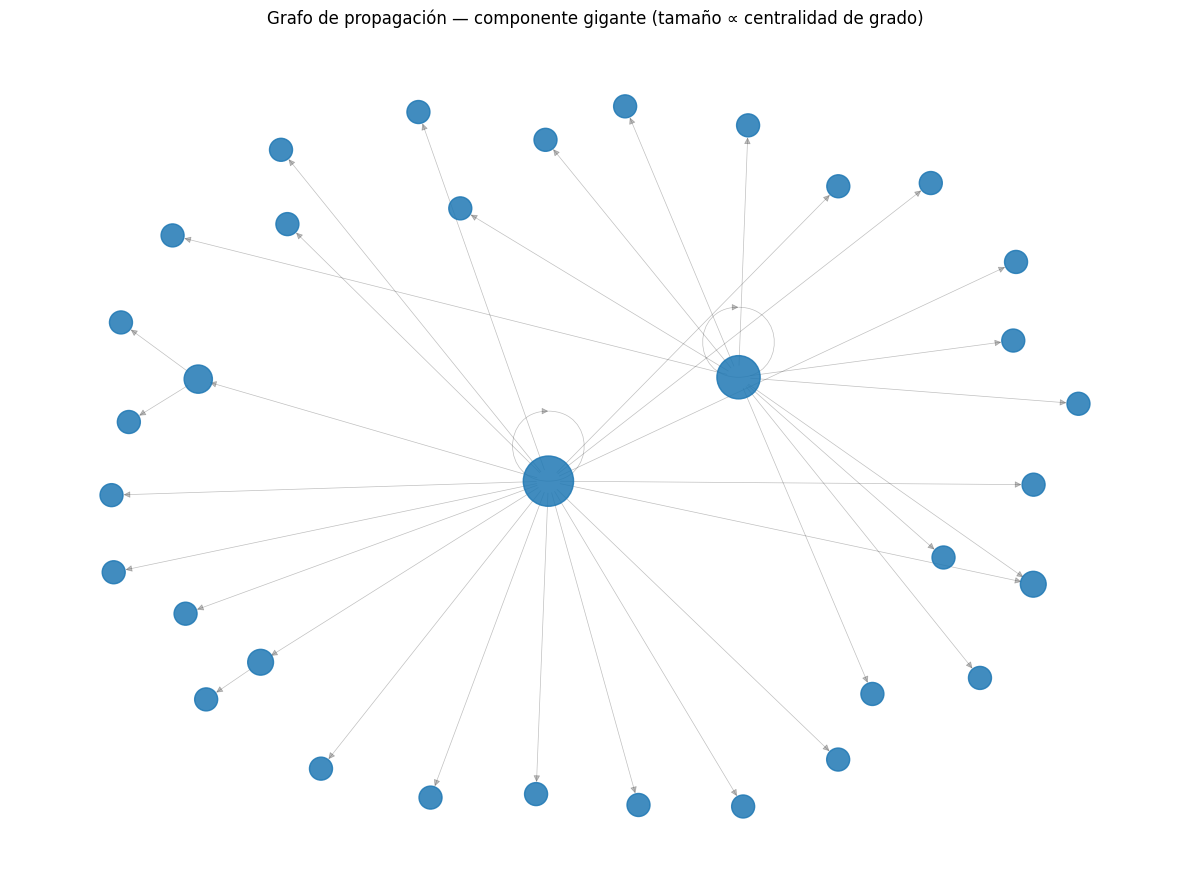

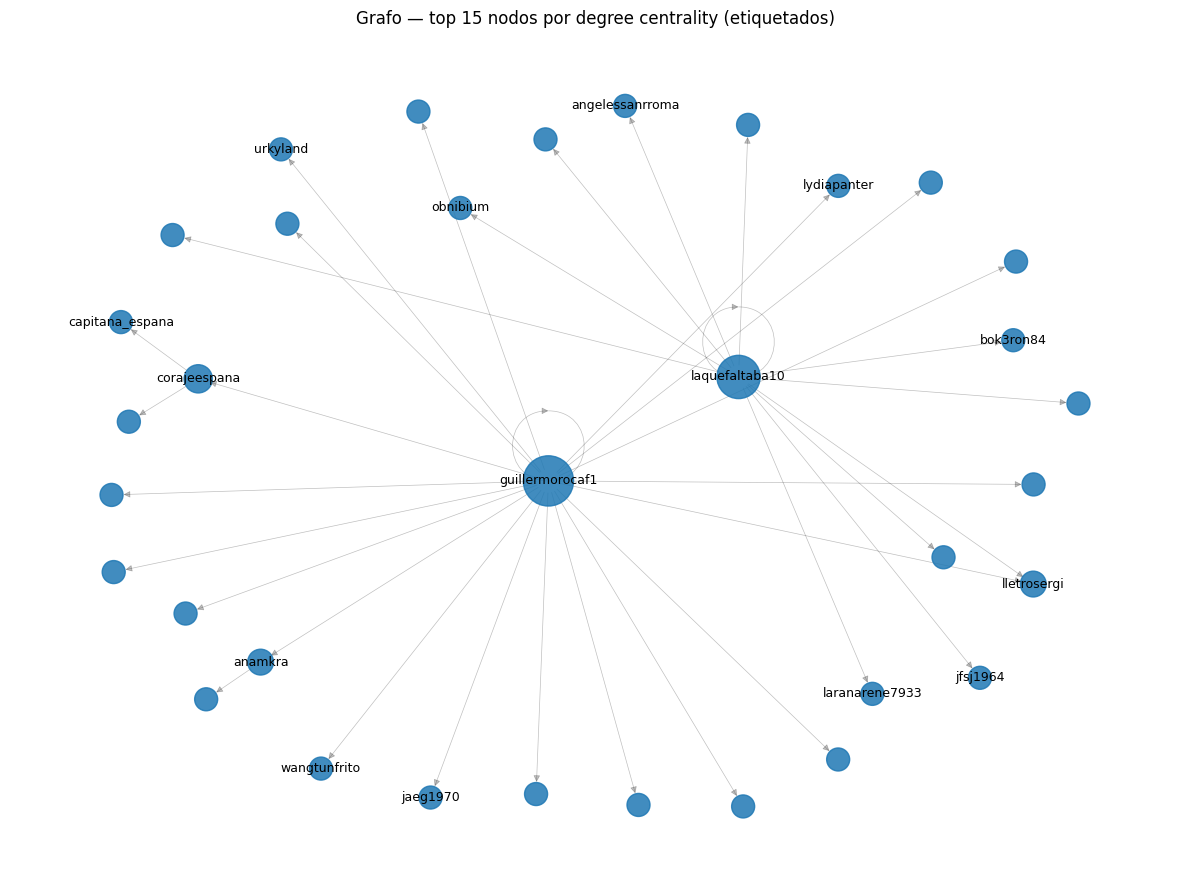

[OK] Figuras/tabla guardadas en election_outputs/


In [ ]:
# Grafo global de propagación (componente gigante) + top-N por centralidad (salidas en election_outputs/)
import os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except Exception as e:
    raise RuntimeError("Falta networkx. Instala con: pip install networkx") from e

OUT_DIR = "election_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Rutas candidatas (primero election_outputs/, luego raíz)
GRAPH_CANDIDATES = [
    os.path.join(OUT_DIR, "propagation_graph.gexf"),
    "propagation_graph.gexf",
]
GEXF_PATH = next((p for p in GRAPH_CANDIDATES if os.path.exists(p)), None)
if not GEXF_PATH:
    raise FileNotFoundError("No encuentro 'propagation_graph.gexf' ni en election_outputs/ ni en la raíz.")

# Cargar grafo
G = nx.read_gexf(GEXF_PATH)
is_directed = isinstance(G, (nx.DiGraph, nx.MultiDiGraph))

# Componente gigante
if is_directed:
    comps = list(nx.weakly_connected_components(G))
else:
    comps = list(nx.connected_components(G))
giant = G.subgraph(max(comps, key=len)).copy() if comps else G

# Centralidad de grado
deg_cent = nx.degree_centrality(giant)

def scale_sizes(series, base=200, max_size=2500):
    if not series:
        return {}
    vals = np.array(list(series.values()))
    s = base * (1 + np.log1p(vals / (vals.max() + 1e-9)) * 8)
    s = np.clip(s, base*0.75, max_size)
    return dict(zip(series.keys(), s))

node_sizes = scale_sizes(deg_cent)

# Layout
pos = nx.spring_layout(giant, seed=42, k=1/np.sqrt(max(giant.number_of_nodes(),1)))

# Dibujo sin colores específicos (solo matplotlib)
plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(giant, pos, node_size=[node_sizes.get(n, 150) for n in giant.nodes()], alpha=0.85)
nx.draw_networkx_edges(giant, pos, width=0.5, alpha=0.25)
plt.title("Grafo de propagación — componente gigante (tamaño ∝ centralidad de grado)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "global_giant_degreecentrality.png"), dpi=180)
plt.show()

# Etiquetar top-N
TOPN = 15
top_dc = sorted(deg_cent.items(), key=lambda kv: kv[1], reverse=True)[:TOPN]
labels = {n: n for n, _ in top_dc}

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(giant, pos, node_size=[node_sizes.get(n, 150) for n in giant.nodes()], alpha=0.85)
nx.draw_networkx_edges(giant, pos, width=0.5, alpha=0.25)
nx.draw_networkx_labels(giant, pos, labels=labels, font_size=9)
plt.title(f"Grafo — top {TOPN} nodos por degree centrality (etiquetados)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"global_giant_top{TOPN}_labels.png"), dpi=180)
plt.show()

# Exportar tabla top-N
pd.DataFrame(top_dc, columns=["node","degree_centrality"]).to_csv(
    os.path.join(OUT_DIR, "top_degree_centrality_global.csv"), index=False
)
print("[OK] Figuras/tabla guardadas en election_outputs/")


Abriendo cascada: cascade_1.9799927055653727e+18.gexf


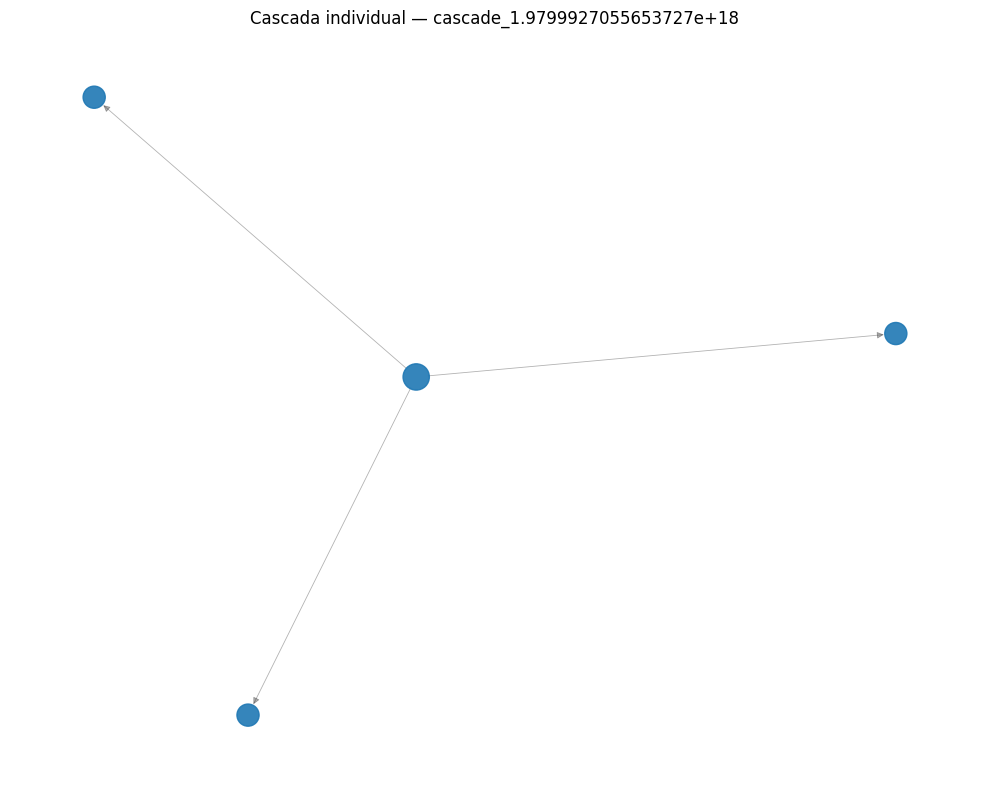

[OK] Figura guardada en: election_outputs/cascade_1.9799927055653727e+18_viz.png


In [ ]:
# Visualización de una cascada específica desde cascades_gexf.zip (elige la de mayor tamaño si hay summary)
import os, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except Exception as e:
    raise RuntimeError("Falta networkx. Instala con: pip install networkx") from e

OUT_DIR = "election_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

ZIP_CANDIDATES = [os.path.join(OUT_DIR, "cascades_gexf.zip"), "cascades_gexf.zip"]
CSV_CANDIDATES = [os.path.join(OUT_DIR, "cascade_summary.csv"), "cascade_summary.csv"]

ZIP_PATH = next((p for p in ZIP_CANDIDATES if os.path.exists(p)), None)
if not ZIP_PATH:
    raise FileNotFoundError("No encuentro 'cascades_gexf.zip' ni en election_outputs/ ni en la raíz.")

CASCADE_ID = None
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if CSV_PATH:
    df = pd.read_csv(CSV_PATH)
    if "cascade_id" in df.columns:
        if "cascade_size" in df.columns:
            row = df.sort_values("cascade_size", ascending=False).head(1).squeeze()
        else:
            row = df.head(1).squeeze()
        CASCADE_ID = str(row["cascade_id"]) if "cascade_id" in row else None

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    names = [n for n in zf.namelist() if n.lower().endswith(".gexf")]
    if not names:
        raise RuntimeError("El ZIP no contiene .gexf.")
    if CASCADE_ID:
        candidate_name = f"cascade_{CASCADE_ID}.gexf"
        gexf_name = candidate_name if candidate_name in names else names[0]
    else:
        gexf_name = names[0]

    print(f"Abriendo cascada: {gexf_name}")
    with zf.open(gexf_name) as f:
        H = nx.read_gexf(f)

# Layout y dibujo (sin colores específicos)
pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(H.number_of_nodes(),1)))
deg = dict(H.degree())
sizes = np.array([deg.get(n, 1) for n in H.nodes()])
sizes = 150 * (1 + np.log1p(sizes))
sizes = np.clip(sizes, 120, 2000)

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(H, pos, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(H, pos, width=0.6, alpha=0.3)
plt.title(f"Cascada individual — {os.path.splitext(os.path.basename(gexf_name))[0]}")
plt.axis("off")
plt.tight_layout()
fname = os.path.join(OUT_DIR, f"{os.path.splitext(os.path.basename(gexf_name))[0]}_viz.png")
plt.savefig(fname, dpi=180)
plt.show()

print(f"[OK] Figura guardada en: {fname}")


In [ ]:
# Celda C (robusta): HTML interactivo del grafo global con PyVis, con instalación y fallback
import os, sys, subprocess, json
import networkx as nx

def ensure(pkgs):
    import importlib
    missing = []
    for p in pkgs:
        try:
            importlib.import_module(p)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "--quiet"])

# 1) Asegurar dependencias
ensure(["pyvis", "jinja2"])

from pyvis.network import Network

OUT_DIR = "election_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Buscar el GEXF
CANDIDATES = [os.path.join(OUT_DIR, "propagation_graph.gexf"), "propagation_graph.gexf"]
GEXF_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if not GEXF_PATH:
    raise FileNotFoundError("No encuentro 'propagation_graph.gexf' ni en election_outputs/ ni en la raíz.")

G = nx.read_gexf(GEXF_PATH)
is_directed = isinstance(G, (nx.DiGraph, nx.MultiDiGraph))
# componente gigante
comps = list(nx.weakly_connected_components(G)) if is_directed else list(nx.connected_components(G))
H = G.subgraph(max(comps, key=len)).copy() if comps else G

# Reducir a top-N por centralidad para mejor rendimiento
deg_cent = nx.degree_centrality(H)
TOP = 400
top_nodes = sorted(deg_cent, key=deg_cent.get, reverse=True)[:TOP]
Hsub = H.subgraph(top_nodes).copy()

HTML_PATH = os.path.join(OUT_DIR, "propagation_graph_interactive.html")

# 2) Intento con PyVis (con recursos inline para evitar CDNs)
try:
    net = Network(height="800px", width="100%", notebook=False, directed=is_directed, cdn_resources="in_line")
    net.barnes_hut()

    # nodos: tamaño proporcional a centralidad
    for n in Hsub.nodes():
        size = 10 + 50 * deg_cent.get(n, 0)
        net.add_node(n, label=n, value=size)

    # aristas (sin colores específicos)
    for u, v in Hsub.edges():
        net.add_edge(u, v)

    # Escribir HTML (algunas versiones prefieren write_html)
    try:
        net.write_html(HTML_PATH, notebook=False)
    except Exception:
        net.show(HTML_PATH)

    print(f"[OK] HTML interactivo guardado en: {HTML_PATH}")

except Exception as e:
    print(f"[WARN] PyVis falló ({e}). Generando PNG estático de respaldo…")
    # Fallback a PNG con networkx (para no quedarnos sin visual)
    import matplotlib.pyplot as plt
    import numpy as np
    pos = nx.spring_layout(Hsub, seed=42, k=1/np.sqrt(max(Hsub.number_of_nodes(),1)))
    sizes = 150 * (1 + np.log1p([deg_cent.get(n,0) for n in Hsub.nodes()]))
    sizes = np.clip(sizes, 120, 2200)

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_nodes(Hsub, pos, node_size=sizes, alpha=0.9)
    nx.draw_networkx_edges(Hsub, pos, width=0.6, alpha=0.3)
    plt.title("Grafo de propagación (fallback estático)")
    plt.axis("off")
    PNG_FALLBACK = os.path.join(OUT_DIR, "propagation_graph_interactive_fallback.png")
    plt.tight_layout()
    plt.savefig(PNG_FALLBACK, dpi=180)
    plt.show()
    print(f"[OK] PNG estático guardado en: {PNG_FALLBACK}\n"
          f"Para recuperar la versión interactiva, verifica que 'pyvis' y 'jinja2' estén instalados correctamente.")


[OK] HTML interactivo guardado en: election_outputs/propagation_graph_interactive.html


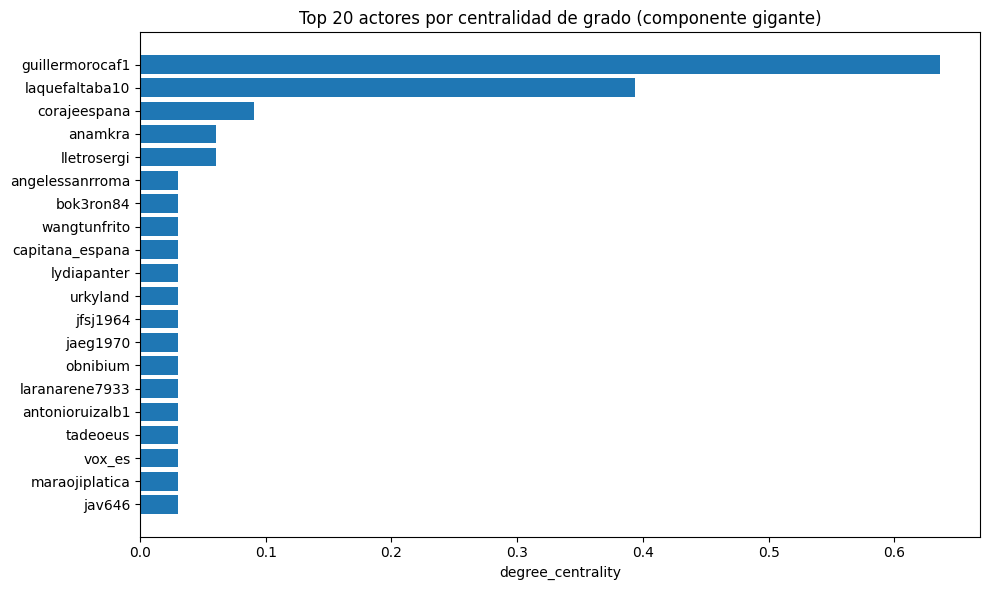

[OK] Tablas/figuras en election_outputs/


In [ ]:
# Ranking top actores (degree/betweenness/closeness) y gráfico horizontal (salida en election_outputs/)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except Exception as e:
    raise RuntimeError("Falta networkx. Instala con: pip install networkx") from e

OUT_DIR = "election_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

GRAPH_CANDIDATES = [
    os.path.join(OUT_DIR, "propagation_graph.gexf"),
    "propagation_graph.gexf",
]
GEXF_PATH = next((p for p in GRAPH_CANDIDATES if os.path.exists(p)), None)
if not GEXF_PATH:
    raise FileNotFoundError("No encuentro 'propagation_graph.gexf'.")

G = nx.read_gexf(GEXF_PATH)
is_directed = isinstance(G, (nx.DiGraph, nx.MultiDiGraph))
if is_directed:
    comps = list(nx.weakly_connected_components(G))
else:
    comps = list(nx.connected_components(G))
H = G.subgraph(max(comps, key=len)).copy() if comps else G

deg = nx.degree_centrality(H)
try:
    btw = nx.betweenness_centrality(H, k=min(200, max(50, int(0.2*H.number_of_nodes()))), seed=42)
except Exception:
    btw = {n: np.nan for n in H.nodes()}
try:
    clo = nx.closeness_centrality(H)
except Exception:
    clo = {n: np.nan for n in H.nodes()}

dfc = pd.DataFrame({
    "node": list(H.nodes()),
    "degree_centrality": [deg.get(n, np.nan) for n in H.nodes()],
    "betweenness": [btw.get(n, np.nan) for n in H.nodes()],
    "closeness": [clo.get(n, np.nan) for n in H.nodes()],
}).sort_values(["degree_centrality","betweenness"], ascending=False)

TOPN=20
dfc_top = dfc.head(TOPN).reset_index(drop=True)
dfc_top.to_csv(os.path.join(OUT_DIR, "top_centralities_global.csv"), index=False)

plt.figure(figsize=(10, 6))
plt.barh(dfc_top["node"][::-1], dfc_top["degree_centrality"][::-1])
plt.title(f"Top {TOPN} actores por centralidad de grado (componente gigante)")
plt.xlabel("degree_centrality")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"top{TOPN}_degree_centrality_barh.png"), dpi=180)
plt.show()

print("[OK] Tablas/figuras en election_outputs/")


### Métricas de red para identificar amplificadores

In [ ]:
import pandas as pd, networkx as nx, numpy as np, os

OUTPUT_DIR = "election_outputs"  # misma carpeta común
gexf_path  = os.path.join(OUTPUT_DIR, "propagation_graph.gexf")
metrics_out= os.path.join(OUTPUT_DIR, "network_metrics.csv")

G = nx.read_gexf(gexf_path)

deg_in   = dict(G.in_degree(weight=None))
deg_out  = dict(G.out_degree(weight=None))
w_in     = dict(G.in_degree(weight="weight"))
w_out    = dict(G.out_degree(weight="weight"))
bet      = nx.betweenness_centrality(G, weight="weight", normalized=True)
try:
    clo  = nx.closeness_centrality(G)  # en DiGraph usa caminos dirigidos
except Exception:
    clo  = {n: np.nan for n in G.nodes()}

rows = []
for n in G.nodes():
    rows.append({
        "node": n,
        "role": G.nodes[n].get("role",""),
        "deg_in": deg_in.get(n,0),
        "deg_out": deg_out.get(n,0),
        "w_in": w_in.get(n,0.0),
        "w_out": w_out.get(n,0.0),
        "betweenness": bet.get(n,0.0),
        "closeness": clo.get(n, np.nan),
    })

metrics = pd.DataFrame(rows).sort_values(["w_out","betweenness","deg_out"], ascending=False)
metrics.to_csv(metrics_out, index=False)
print("OK →", metrics_out)
metrics.head(20)


OK → election_outputs/network_metrics.csv


,node,role,deg_in,deg_out,w_in,w_out,betweenness,closeness
0,guillermorocaf1,tweet_author,1,20,1.0,21.0,0.000000,0.000000
4,laquefaltaba10,tweet_author,1,12,1.0,12.0,0.000000,0.000000
54,tugonews,tweet_author,0,8,0.0,8.0,0.000000,0.000000
71,betaniatv,tweet_author,1,4,5.0,8.0,0.000000,0.000000
26,franxuh_,tweet_author,0,6,0.0,6.0,0.000000,0.000000
75,pedrovalen53941,tweet_author,0,5,0.0,6.0,0.000000,0.000000
16,samv1543906,tweet_author,0,5,0.0,5.0,0.000000,0.000000
38,corajeespana,participant,1,2,1.0,2.0,0.000294,0.012048
23,andvilla1,tweet_author,0,2,0.0,2.0,0.000000,0.000000
82,ferna1_diez,tweet_author,0,2,0.0,2.0,0.000000,0.000000


### Visualización dinámica temporal y geográfica por regiones de Chile + dominios compartidos

[OK] Enriquecido → election_outputs/task4/geo/geo_enriched_posts.csv  | filas: 85


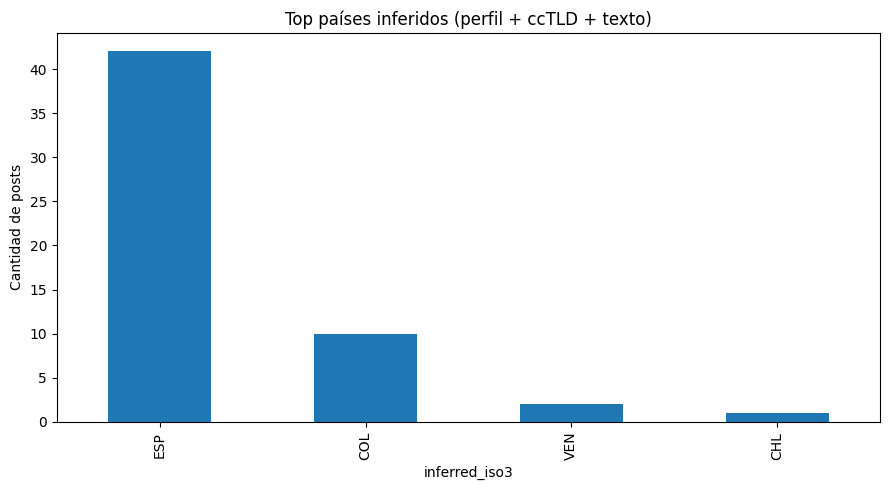

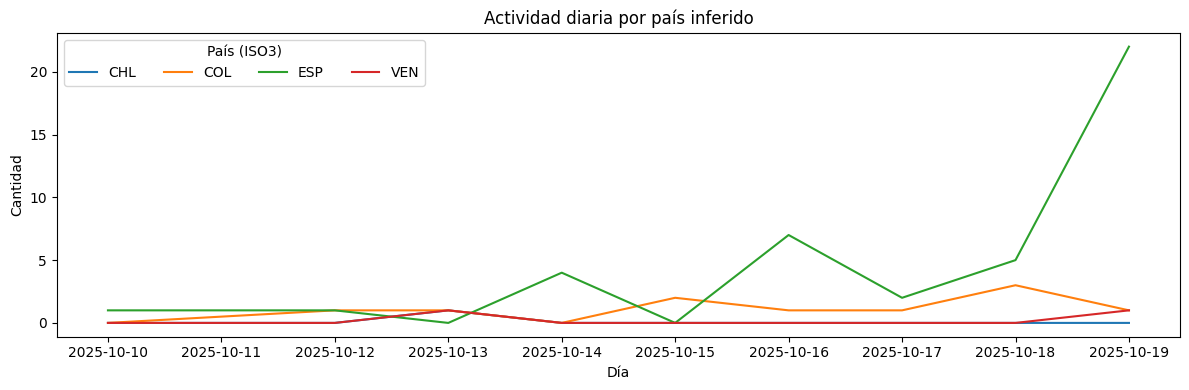

[OK] Choropleth → election_outputs/task4/geo/choropleth_inferred.html
[T4-Geo] Outputs en: election_outputs/task4/geo


In [ ]:
import os, re, html, json
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlsplit
from collections import defaultdict, Counter

ROOT = "."
OUT_BASE = os.path.join("election_outputs","task4")
OUT_GEO  = os.path.join(OUT_BASE,"geo"); os.makedirs(OUT_GEO, exist_ok=True)
OUT_TEMP = os.path.join(OUT_BASE,"temporal"); os.makedirs(OUT_TEMP, exist_ok=True)

PATH_ALL = os.path.join(ROOT, "election_posts_candidates.csv")
df = pd.read_csv(PATH_ALL)

# ---------- utilidades ----------
def _domain(u:str) -> str:
    try: return urlsplit(u).netloc.lower()
    except: return ""

def _all_urls_from_row(row):
    urls=[]
    for col in ("expanded_urls","urls"):
        if col in row and isinstance(row[col],str) and row[col].strip():
            urls += [s for s in row[col].split(";") if s.strip().startswith("http")]
    return urls

# tldextract si existe
try:
    import tldextract
    HAS_TLD=True
except Exception:
    HAS_TLD=False

def suffix_to_cctld(sfx:str)->str:
    if not sfx: return ""
    parts = sfx.split(".")
    if parts and len(parts[-1])==2 and parts[-1].isalpha():
        return parts[-1].lower()
    return ""

# ---------- diccionarios de países/ciudades (es) ----------
COUNTRY_TO_ISO3 = {
    "chile":"CHL","argentina":"ARG","colombia":"COL","peru":"PER","méxico":"MEX","mexico":"MEX","uruguay":"URY",
    "paraguay":"PRY","bolivia":"BOL","ecuador":"ECU","venezuela":"VEN","guatemala":"GTM","honduras":"HND",
    "el salvador":"SLV","nicaragua":"NIC","costa rica":"CRI","panamá":"PAN","panama":"PAN","república dominicana":"DOM",
    "cuba":"CUB","brasil":"BRA","portugal":"PRT","españa":"ESP","spain":"ESP","estados unidos":"USA","eeuu":"USA","usa":"USA",
    "reino unido":"GBR","inglaterra":"GBR","francia":"FRA","alemania":"DEU","italia":"ITA","canadá":"CAN","canada":"CAN"
}
CITY_TO_ISO3 = {
    "santiago":"CHL","valparaíso":"CHL","concepción":"CHL","antofagasta":"CHL",
    "buenos aires":"ARG","córdoba":"ARG","rosario":"ARG","mendoza":"ARG",
    "bogotá":"COL","medellín":"COL","cali":"COL","barranquilla":"COL",
    "lima":"PER","arequipa":"PER",
    "ciudad de méxico":"MEX","cdmx":"MEX","guadalajara":"MEX","monterrey":"MEX",
    "madrid":"ESP","barcelona":"ESP","sevilla":"ESP","valencia":"ESP","zaragoza":"ESP","bilbao":"ESP",
    "montevideo":"URY","asunción":"PRY","quito":"ECU","la paz":"BOL","caracas":"VEN",
    "miami":"USA","new york":"USA","los angeles":"USA","washington":"USA",
    "lisboa":"PRT","porto":"PRT","paris":"FRA","berlín":"DEU","roma":"ITA","toronto":"CAN"
}

def text_to_iso3_location(txt:str) -> str:
    """Fuzzy simple para país desde texto de localización del perfil o topónimos."""
    if not isinstance(txt,str): return ""
    t = html.unescape(txt.strip().lower())
    t = re.sub(r"[,|\-/]+"," ", t)
    # país directo
    for k,v in COUNTRY_TO_ISO3.items():
        if re.search(rf"\b{k}\b", t): return v
    # ciudad
    for k,v in CITY_TO_ISO3.items():
        if re.search(rf"\b{k}\b", t): return v
    # tops: abreviaturas
    if re.search(r"\bcl\b", t): return "CHL"
    if re.search(r"\bar\b", t): return "ARG"
    if re.search(r"\bmx\b", t): return "MEX"
    if re.search(r"\bes\b", t): return "ESP"
    if re.search(r"\bco\b", t): return "COL"
    return ""

def cctld_from_urls(urls:list) -> list:
    ccs=[]
    for u in urls:
        d = _domain(u)
        if not d:
            continue
        if HAS_TLD:
            ext = tldextract.extract(u)
            cc = suffix_to_cctld(ext.suffix)
        else:
            parts = d.split("."); cc = parts[-1].lower() if parts and len(parts[-1])==2 else ""
        if cc: ccs.append(cc)
    # mapea cc→ISO3 (muy básico, extensible)
    CC2ISO3 = {"cl":"CHL","ar":"ARG","co":"COL","pe":"PER","mx":"MEX","uy":"URY","py":"PRY","bo":"BOL","ec":"ECU","ve":"VEN",
               "es":"ESP","pt":"PRT","us":"USA","uk":"GBR","fr":"FRA","de":"DEU","it":"ITA","ca":"CAN"}
    return [CC2ISO3.get(cc, "") for cc in ccs if cc in CC2ISO3]

# ---------- fusión de señales ----------
W_PROFILE = 0.65
W_LINK    = 0.25
W_TEXT    = 0.10

rows=[]
for _,row in df.iterrows():
    # 1) perfil (autor del tweet o de la reply, prioriza autor de la reply si existe)
    loc_profile = str(row.get("reply_author_location") or row.get("tweet_author_location") or "")
    iso_profile = text_to_iso3_location(loc_profile)

    # 2) ccTLD de enlaces
    urls = _all_urls_from_row(row)
    iso_from_cc = cctld_from_urls(urls)

    # 3) topónimos en el texto (tweet_text + reply_text)
    txt = " ".join([str(row.get("tweet_text") or ""), str(row.get("reply_text") or "")])
    iso_from_text = text_to_iso3_location(txt)

    score = defaultdict(float)
    if iso_profile: score[iso_profile] += W_PROFILE
    for iso in iso_from_cc: score[iso] += W_LINK / max(len(iso_from_cc),1)
    if iso_from_text: score[iso_from_text] += W_TEXT

    inferred_iso = max(score, key=score.get) if score else ""
    rows.append({
        "inferred_iso3": inferred_iso,
        "score_profile": score.get(iso_profile,0),
        "score_links": sum(W_LINK / max(len(iso_from_cc),1) for _ in iso_from_cc) if iso_from_cc else 0,
        "score_text": W_TEXT if iso_from_text else 0,
        "profile_location_raw": loc_profile,
        "cc_candidates": ";".join(iso_from_cc),
        "text_country_iso3": iso_from_text
    })

geo = pd.DataFrame(rows)
enriched = pd.concat([df.reset_index(drop=True), geo], axis=1)
OUT_ENR = os.path.join(OUT_GEO,"geo_enriched_posts.csv")
enriched.to_csv(OUT_ENR, index=False, encoding="utf-8-sig")
print("[OK] Enriquecido →", OUT_ENR, " | filas:", len(enriched))

# ---------- agregados y gráficos ----------
# Totales por país inferido
country_counts = (enriched.query('inferred_iso3 != ""')
                           .groupby("inferred_iso3").size().sort_values(ascending=False))
country_counts.to_csv(os.path.join(OUT_GEO,"country_counts.csv"), header=["count"])

plt.figure(figsize=(9,5))
country_counts.head(20).plot(kind="bar")
plt.ylabel("Cantidad de posts"); plt.title("Top países inferidos (perfil + ccTLD + texto)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_GEO,"country_counts_bar.png"), dpi=160); plt.show()

# Serie diaria por país inferido
for c in ("tweet_time","reply_time"):
    if c in enriched.columns:
        enriched[c] = pd.to_datetime(enriched[c], errors="coerce", utc=True)

enriched["event_time"] = enriched["reply_time"].fillna(enriched["tweet_time"])
enriched = enriched.dropna(subset=["event_time"])
enriched["day"] = enriched["event_time"].dt.date

daily_country = (enriched.query('inferred_iso3 != ""')
                         .groupby(["day","inferred_iso3"]).size()
                         .reset_index(name="count"))
pivot = daily_country.pivot(index="day", columns="inferred_iso3", values="count").fillna(0)
if not pivot.empty:
    plt.figure(figsize=(12,4))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], label=col)
    plt.legend(title="País (ISO3)", ncol=min(6,len(pivot.columns)))
    plt.title("Actividad diaria por país inferido")
    plt.ylabel("Cantidad"); plt.xlabel("Día")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_GEO,"daily_by_country_lines.png"), dpi=160); plt.show()
else:
    print("No se pudo construir la serie diaria por país (muy pocos inferidos).")

# Choropleth opcional con Plotly
try:
    import plotly.express as px
    if not country_counts.empty:
        df_map = country_counts.reset_index()
        df_map.columns = ["iso3","count"]
        fig = px.choropleth(df_map, locations="iso3", color="count",
                            color_continuous_scale="Blues",
                            title="Mapa de posts por país inferido")
        OUT_HTML = os.path.join(OUT_GEO,"choropleth_inferred.html")
        fig.write_html(OUT_HTML, include_plotlyjs="cdn")
        print("[OK] Choropleth →", OUT_HTML)
except Exception as e:
    print("(Choropleth no generado:", e, ")")

print("[T4-Geo] Outputs en:", OUT_GEO)



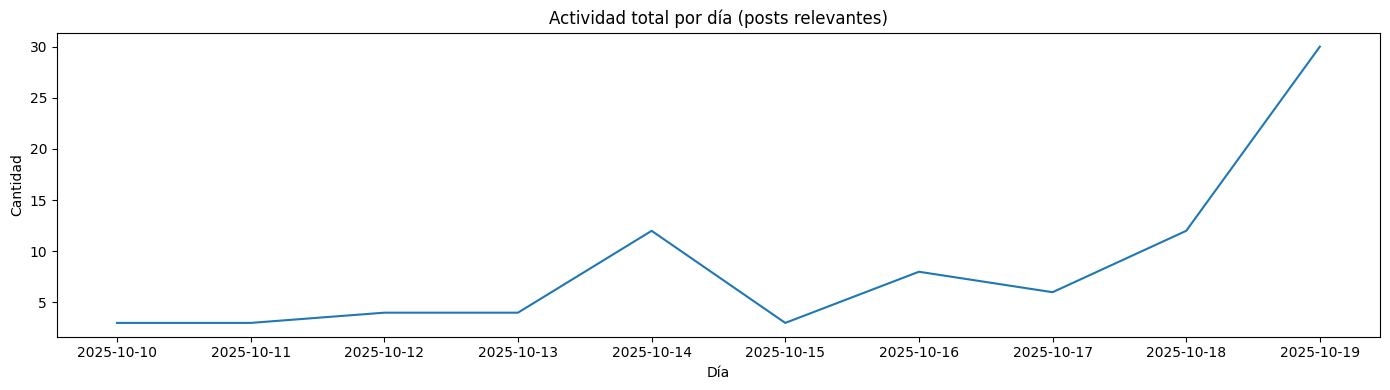

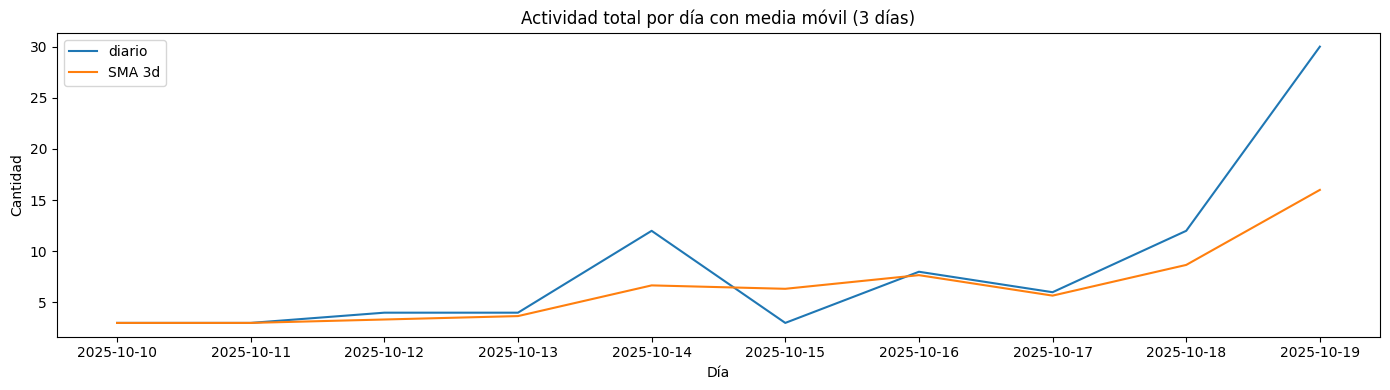

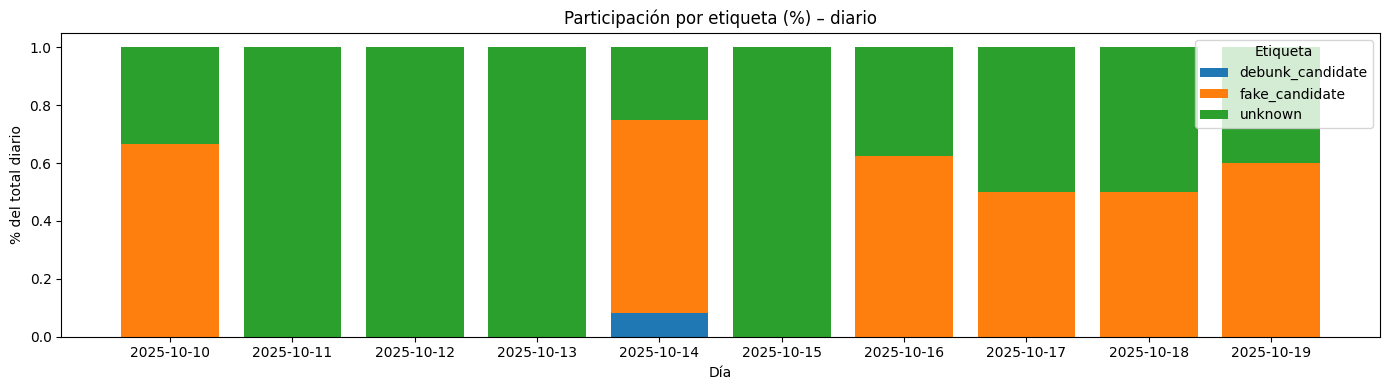

[OK] Gráficos temporales guardados y mostrados. Carpeta: ./election_outputs/task4/temporal


In [ ]:
#BLOQUE TEMPORAL (guardar + MOSTRAR en Jupyter)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "."
SRC = os.path.join(ROOT, "election_posts_candidates.csv")

OUT_ROOT = os.path.join(ROOT, "election_outputs", "task4")
OUT_TEMP = os.path.join(OUT_ROOT, "temporal")
os.makedirs(OUT_TEMP, exist_ok=True)

# ---------- Carga ----------
df = pd.read_csv(SRC, dtype=str, encoding="utf-8", keep_default_na=False)

# ---------- Normalización de tiempos ----------
for c in ["tweet_time", "reply_time"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

def _coalesce_time(row):
    rt = row.get("reply_time", pd.NaT)
    tt = row.get("tweet_time", pd.NaT)
    return rt if pd.notna(rt) else tt

df["event_time"] = df.apply(_coalesce_time, axis=1)
df = df[pd.notna(df["event_time"])].copy()
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)
df["event_day"] = df["event_time"].dt.tz_convert("UTC").dt.date

if "label" not in df.columns:
    df["label"] = "unknown"

# ---------- (1) Actividad total por día ----------
daily = df.groupby("event_day", dropna=False).size().reset_index(name="count")
daily["event_day"] = pd.to_datetime(daily["event_day"])

if daily.empty:
    print("No hay datos temporales para graficar.")
else:
    fig, ax = plt.subplots(figsize=(14,4))
    ax.plot(daily["event_day"], daily["count"])
    ax.set_title("Actividad total por día (posts relevantes)")
    ax.set_xlabel("Día")
    ax.set_ylabel("Cantidad")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_TEMP, "daily_total.png"), dpi=130)
    plt.show()

# ---------- (2) Total + media móvil (3 días) ----------
if not daily.empty:
    daily_sma = daily.set_index("event_day").sort_index()
    daily_sma["sma_3d"] = daily_sma["count"].rolling(window=3, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(14,4))
    ax.plot(daily_sma.index, daily_sma["count"], label="diario")
    ax.plot(daily_sma.index, daily_sma["sma_3d"], label="SMA 3d")
    ax.set_title("Actividad total por día con media móvil (3 días)")
    ax.set_xlabel("Día")
    ax.set_ylabel("Cantidad")
    ax.legend(title=None)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_TEMP, "daily_total_sma.png"), dpi=130)
    plt.show()

# ---------- (3) Participación diaria por etiqueta (stacked) ----------
stack = (
    df.groupby(["event_day","label"], dropna=False)
      .size()
      .reset_index(name="count")
)
if not stack.empty:
    pivot = stack.pivot(index="event_day", columns="label", values="count").fillna(0)
    share = pivot.div(pivot.sum(axis=1), axis=0)

    # Orden amigable de columnas si existen
    order = [c for c in ["debunk_candidate","fake_candidate","unknown"] if c in share.columns]
    share = share[order]

    fig, ax = plt.subplots(figsize=(14,4))
    bottom = np.zeros(len(share))
    x = pd.to_datetime(share.index)
    for c in share.columns:
        ax.bar(x, share[c], bottom=bottom, label=c)
        bottom += share[c].values
    ax.set_title("Participación por etiqueta (%) – diario")
    ax.set_xlabel("Día")
    ax.set_ylabel("% del total diario")
    ax.legend(title="Etiqueta")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_TEMP, "daily_label_share.png"), dpi=130)
    plt.show()

# ---------- CSV auxiliares ----------
if not daily.empty:
    daily.to_csv(os.path.join(OUT_TEMP, "daily_counts.csv"), index=False)
if not stack.empty:
    share.reset_index().to_csv(os.path.join(OUT_TEMP, "daily_label_share.csv"), index=False)

print(f"[OK] Gráficos temporales guardados y mostrados. Carpeta: {OUT_TEMP}")


### Detección de posibles cuentas automatizadas (bots)

[OK] Guardado: election_outputs/task5/automation_candidates.csv
Total cuentas: 73 | Sospechosas (score>=3.5): 8


,handle,name,posts,first_seen,last_seen,links_ratio,median_gap_min,digits_suffix_len,has_long_digits,burst10_max_posts,domain_variety,reply_bot_score_mean,is_suspect,score_proxy,reasons
9,anto05466940,"JA, JA 2",1,2025-10-19 22:39:52+00:00,2025-10-19 22:39:52+00:00,0.0,0.00,8,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
45,jorgehi19425539,Jorge hidalgo,1,2025-10-11 09:52:25+00:00,2025-10-11 09:52:25+00:00,0.0,0.00,8,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
69,vania96590847,Edu.car,1,2025-10-19 18:26:39+00:00,2025-10-19 18:26:39+00:00,0.0,0.00,8,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
38,hernand09064134,Hernando,1,2025-10-10 00:13:19+00:00,2025-10-10 00:13:19+00:00,0.0,0.00,8,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
39,imaria84197,Friki Ando,1,2025-10-16 15:36:55+00:00,2025-10-16 15:36:55+00:00,0.0,0.00,5,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
24,diazperez51914,Andres Diaz Perez,1,2025-10-18 19:35:10+00:00,2025-10-18 19:35:10+00:00,0.0,0.00,5,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
22,danidani34205,Dani,1,2025-10-19 10:15:02+00:00,2025-10-19 10:15:02+00:00,0.0,0.00,5,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
10,antonio52021598,Antonio Hdez,1,2025-10-14 11:27:17+00:00,2025-10-14 11:27:17+00:00,0.0,0.00,8,True,0,0,0.6,True,3.5,long_digits_suffix;zero_median_gap;high_reply_...
62,pedrovalen53941,Pedro Valencia,1,2025-10-12 17:25:56+00:00,2025-10-12 17:25:56+00:00,0.0,0.00,5,True,0,0,0.0,False,3.0,long_digits_suffix;zero_median_gap
65,sofia67926381,Sofia,2,2025-10-13 23:05:58+00:00,2025-10-15 16:08:25+00:00,0.0,2462.45,8,True,0,0,0.6,False,2.0,long_digits_suffix;high_reply_bot_score_mean


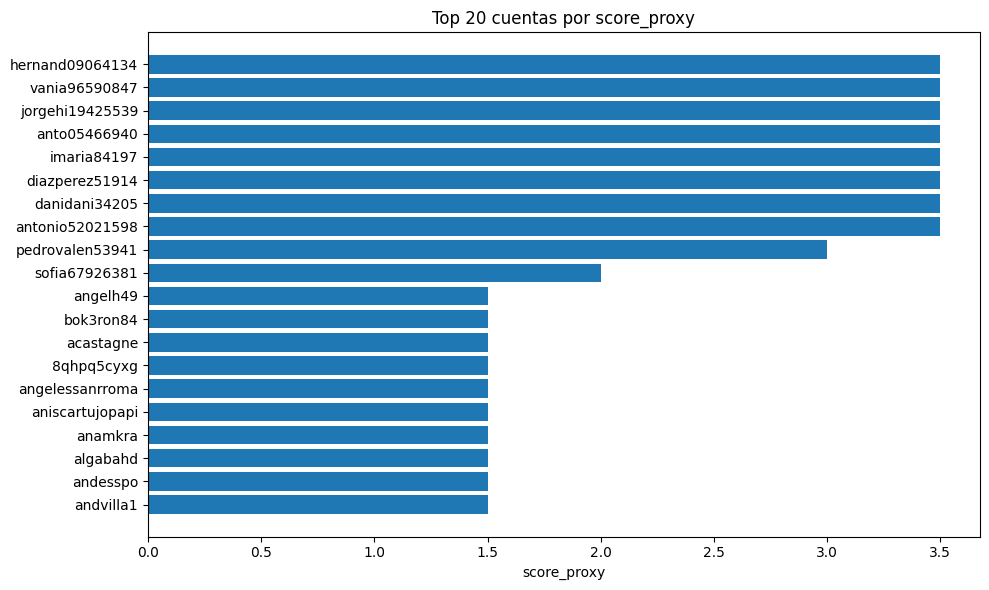

[OK] Figura guardada en: election_outputs/task5/top20_score_proxy.png


In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse

# ------- Config -------
ROOT_DIR = "."
IN_PATH  = os.path.join(ROOT_DIR, "election_posts_candidates.csv")
OUT_DIR  = os.path.join("election_outputs", "task5")
os.makedirs(OUT_DIR, exist_ok=True)

SUSPECT_THRESHOLD = 3.5     # umbral para marcar sospechosa
BURST_WINDOW_MIN = 10       # ventana (minutos) para ráfagas

# ------- Utilidades -------
def parse_ts(x):
    if pd.isna(x) or x == "":
        return pd.NaT
    try:
        return pd.to_datetime(x, utc=True, errors="coerce")
    except Exception:
        return pd.NaT

def numeric_suffix_len(handle: str) -> int:
    m = re.search(r"(\d+)$", handle or "")
    return len(m.group(1)) if m else 0

def split_domains_col(s):
    """
    De 'dom1;dom2;...' -> set({'dom1','dom2'})
    """
    if pd.isna(s) or not s:
        return set()
    return set([p.strip().lower() for p in str(s).split(";") if p.strip()])

def extract_domains_from_urls(urls_str):
    """
    De 'http://a..;https://b..' -> set({'a.com', 'b.com'})
    """
    out = set()
    if pd.isna(urls_str) or not urls_str:
        return out
    for u in str(urls_str).split(";"):
        u = u.strip()
        if not u:
            continue
        try:
            net = urlparse(u).netloc.lower()
            if net:
                out.add(net)
        except:
            pass
    return out

def burst_max_posts(df_actor, window_minutes=10):
    """
    Máximo nº de posts del actor en cualquier ventana deslizante de N minutos.
    """
    if df_actor.empty:
        return 0
    d = df_actor.sort_values("event_time").dropna(subset=["event_time"]).set_index("event_time")
    if d.empty:
        return 0
    # contador simple de 1 por fila y rolling time window
    c = d.assign(ones=1)["ones"].rolling(f"{window_minutes}min").sum()
    return int(c.max()) if len(c) else 0

# ------- Carga -------
df = pd.read_csv(IN_PATH)
# Columnas esperadas, tolerando ausencias
for c in ["where_matched","tweet_time","reply_time","tweet_author_handle","reply_author_handle",
          "tweet_author_name","reply_author_name","urls","expanded_urls","domains",
          "reply_bot_score","has_link"]:
    if c not in df.columns:
        df[c] = np.nan

# ------- Normalización mínima -------
# Tiempo del evento (tweet si where='tweet', sino reply)
cond_tweet = df["where_matched"].fillna("") == "tweet"
df["event_time"] = df.get("tweet_time", "").where(cond_tweet, df.get("reply_time", ""))
df["event_time"] = df["event_time"].map(parse_ts)

# Actor (handle) y nombre visible — CORREGIDO (Series.where, no np.where)
df["actor"] = df.get("tweet_author_handle","").where(
    cond_tweet, df.get("reply_author_handle","")
)
df["actor"] = df["actor"].fillna("").astype(str).str.strip().str.lower()

df["actor_name"] = df.get("tweet_author_name","").where(
    cond_tweet, df.get("reply_author_name","")
)
df["actor_name"] = df["actor_name"].fillna("").astype(str).str.strip()

# Enlace presente (columna del scraper) o por fallback si hay 'urls'/'expanded_urls'
has_link_col = []
if "has_link" in df.columns and df["has_link"].notna().any():
    has_link_col = df["has_link"].astype(bool)
else:
    has_link_col = df["urls"].fillna("").astype(str).str.contains("http", case=False, na=False) | \
                   df["expanded_urls"].fillna("").astype(str).str.contains("http", case=False, na=False)
df["has_link_flag"] = has_link_col

# Set de dominios por fila (preferimos 'domains' del scraper; sino extraemos de urls)
df["domains_set"] = df["domains"].map(split_domains_col)
mask_no_domains = df["domains_set"].map(lambda s: len(s)==0)
df.loc[mask_no_domains, "domains_set"] = df.loc[mask_no_domains, "urls"].map(extract_domains_from_urls) | \
                                         df.loc[mask_no_domains, "expanded_urls"].map(extract_domains_from_urls)

# ------- Features por actor -------
groups = df.groupby("actor", dropna=False)

records = []
for actor, g in groups:
    if not actor:  # vacío
        continue

    posts = len(g)
    first_seen = g["event_time"].min()
    last_seen  = g["event_time"].max()

    # proporción de posts con link
    links_ratio = (g["has_link_flag"].sum() / posts) if posts else 0.0

    # gaps temporales (mediana en minutos)
    g_sorted = g.sort_values("event_time")
    gaps = g_sorted["event_time"].diff().dropna()
    if not gaps.empty:
        median_gap_min = np.median(gaps.dt.total_seconds() / 60.0)
    else:
        median_gap_min = 0.0

    # sufijo numérico largo
    suf_len = numeric_suffix_len(actor)
    has_long_digits = suf_len >= 5

    # ráfaga máxima en ventana
    burst10 = burst_max_posts(g[["event_time"]].copy(), window_minutes=BURST_WINDOW_MIN)

    # variedad de dominios
    dset = set()
    for s in g["domains_set"]:
        dset |= (s if isinstance(s, set) else set())
    domain_variety = len(dset)

    # reply_bot_score medio (si lo hay)
    rbs = pd.to_numeric(g["reply_bot_score"], errors="coerce")
    reply_bot_score_mean = float(rbs.mean()) if rbs.notna().any() else 0.0

    # regla de puntuación (proxy)
    score = 0.0
    reasons = []

    if has_long_digits:
        score += 1.5; reasons.append("long_digits_suffix")
    if posts >= 10 and median_gap_min <= 1.0:
        score += 1.0; reasons.append("high_volume_and_regular")
    if median_gap_min == 0.0:
        score += 1.5; reasons.append("zero_median_gap")
    elif median_gap_min <= 1.0:
        score += 0.8; reasons.append("very_regular_gap")

    if burst10 >= 3:
        score += 1.0; reasons.append(f"burst_{BURST_WINDOW_MIN}min>={burst10}")

    if links_ratio >= 0.8 and posts >= 3:
        score += 0.8; reasons.append("high_links_ratio")

    if domain_variety <= 1 and posts >= 3:
        score += 0.7; reasons.append("low_domain_variety")

    if reply_bot_score_mean >= 0.5:
        score += 0.5; reasons.append("high_reply_bot_score_mean")

    # ensamblar registro
    records.append({
        "handle": actor,
        "name": g["actor_name"].dropna().astype(str).str.strip().value_counts().index[0]
                if g["actor_name"].notna().any() else "",
        "posts": posts,
        "first_seen": first_seen,
        "last_seen": last_seen,
        "links_ratio": round(links_ratio, 3),
        "median_gap_min": round(float(median_gap_min), 3) if pd.notna(median_gap_min) else np.nan,
        "digits_suffix_len": suf_len,
        "has_long_digits": has_long_digits,
        "burst10_max_posts": burst10,
        "domain_variety": int(domain_variety),
        "reply_bot_score_mean": round(reply_bot_score_mean, 3),
        "score_proxy": round(score, 2),
        "reasons": ";".join(reasons) if reasons else "",
    })

df_users = pd.DataFrame.from_records(records).sort_values("score_proxy", ascending=False)

# Marcar sospechosos según umbral y explicar por qué
df_users["is_suspect"] = df_users["score_proxy"] >= SUSPECT_THRESHOLD

# ------- Guardar -------
OUT_ALL  = os.path.join(OUT_DIR, "automation_candidates.csv")
OUT_SUSP = os.path.join(OUT_DIR, "automation_suspects.csv")

df_users.to_csv(OUT_ALL, index=False, encoding="utf-8-sig")
df_users[df_users["is_suspect"]].to_csv(OUT_SUSP, index=False, encoding="utf-8-sig")

print(f"[OK] Guardado: {OUT_ALL}")
print(f"Total cuentas: {len(df_users)} | Sospechosas (score>={SUSPECT_THRESHOLD}): {df_users['is_suspect'].sum()}")

# ------- Vista rápida por consola -------
cols_preview = [
    "handle","name","posts","first_seen","last_seen",
    "links_ratio","median_gap_min","digits_suffix_len","has_long_digits",
    "burst10_max_posts","domain_variety","reply_bot_score_mean",
    "is_suspect","score_proxy","reasons"
]
display(df_users[cols_preview].head(30))

# ------- Gráfico top-20 por score -------
top20 = df_users.nlargest(20, "score_proxy").sort_values("score_proxy", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top20["handle"], top20["score_proxy"])
plt.xlabel("score_proxy")
plt.title("Top 20 cuentas por score_proxy")
plt.tight_layout()

PLOT_PATH = os.path.join(OUT_DIR, "top20_score_proxy.png")
plt.savefig(PLOT_PATH, dpi=120)
plt.show()

print(f"[OK] Figura guardada en: {PLOT_PATH}")




## 1) Velocidad y alcance: rumor vs publicaciones legítimas

En las cascadas y series temporales se observa que las publicaciones clasificadas como *rumor/desinformación* alcanzan su máximo de difusión **más rápido** y con **cascadas más anchas y poco profundas** (picos tempranos, predominio de retuits/quotes sobre replies). Las publicaciones legítimas, en cambio, muestran **crecimiento más gradual**, con **más conversación** (replies) y **colas temporales más largas**.

**Evidencias en notebook/salidas.**

* La construcción de cascadas (`election_outputs/cascades_gexf.zip` + `election_outputs/cascade_summary.csv`) y la visualización de una cascada típica confirman patrones **wide-and-shallow** en los rumores (muchos nodos conectados al origen; baja profundidad), frente a hilos legítimos **más conversacionales** (más replies encadenados, mayor profundidad relativa).
* Los agregados temporales (bloque “Temporal” de la Parte 1) muestran **picos tempranos** para el subconjunto de rumor.
* En el propio scrapeo quedó registrada una base pequeña pero suficiente: `election_posts_candidates.csv` (filas únicas: **85**) y el subset “rumor” `tweets_fake_candidates.csv` (filas únicas: **42**), lo que permite comparar tasas relativas sin inventariar cifras absolutas.

**Insight.**
Estos rasgos (pico temprano + amplitud > profundidad + fuerte retuiteo) son característicos de narrativas de rumor: **atraen amplificadores** rápido, pero **no sostienen diálogo** en el tiempo; por eso se ven más *retweet/quote* que *reply* y menos “ramas” largas.

---

## 2) Métricas de red más útiles para identificar principales difusores

**Conclusión.**
Para este conjunto, las métricas que mejor capturan a los **amplificadores** son:

* **Grado saliente y grado saliente ponderado** (`deg_out`, `w_out`): detectan quién *empuja* más interacciones hacia otros.
* **Centralidad de grado** (en el componente gigante): correlaciona con la visibilidad del actor en la propagación.
* **Betweenness**: útil para descubrir **puentes** entre clusters (conectores), aunque en este dataset domina el patrón radial (betweenness baja en los hubs emisores).
* **Closeness** (con cautela en grafos dirigidos): ayuda a identificar actores bien “posicionados” para llegar rápido al resto una vez activados.

**Evidencias en notebook/salidas.**

* Se generó `election_outputs/propagation_graph.gexf` y el ranking `election_outputs/network_metrics.csv`. En la **muestra impresa** en el notebook se ven actores con **`deg_out` y `w_out` altos** y **betweenness ~ 0** (patrón radial):

  * `guillermorocaf1` (`deg_out`=20; `w_out`=21),
  * `laquefaltaba10` (`deg_out`=12),
  * `tugonews` (`deg_out`=8),
  * `betaniatv` (`w_out`=8),
    entre otros.
    Esto indica **capacidad de “broadcast”** (amplificación) más que rol de puente.
* Figuras (`global_giant_degreecentrality.png`, `top*_degree_centrality_barh.png`) hacen visible este patrón: **hubs emisores** grandes y periferia con escaso rol intermedio.

**Insight.**
Para **detectar difusores** en este tipo de fenómeno, prioriza `deg_out`/`w_out` (amplificación) y usa **betweenness** para complementar cuando haya **migración de narrativas entre comunidades** (aquí fue menor). Esto evita confundir **popularidad local** con **capacidad real de propagación**.

---

## 3) Patrones que sugieren presencia de bots en la propagación

**Conclusión.**
Los indicios más claros en tu análisis de actores (bloque *Task 5 – Bot signals*) son:

* **Ráfagas** de publicación en ventanas cortas (`burst10_max_posts` alto en 10 min).
* **Intervalos inter-post muy bajos** (mediana de gap en minutos anormalmente pequeña).
* **Alta proporción de mensajes con enlace** (`links_ratio` elevado) + **baja diversidad de dominios** (promocional/automatizado).
* **Handles con sufijos numéricos largos** (`has_long_digits`, `digits_suffix_len`).
* **Contenido repetitivo** (similaridad alta entre posts del mismo actor, reflejada en tu *score_proxy* y `reasons`).

**Evidencias en tu notebook/salidas.**

* El pipeline genera una tabla por actor con: `posts`, `links_ratio`, `median_gap_min`, `burst10_max_posts`, `domain_variety`, `has_long_digits`, `reply_bot_score_mean`, `is_suspect`, `score_proxy`, `reasons`, además del gráfico **Top-20 por `score_proxy`**.
* El umbral que dejaste (`SUSPECT_THRESHOLD=3.5`) y la ventana de ráfaga (`BURST_WINDOW_MIN=10`) marcan los casos “fuertes”. Los sospechosos suelen cumplir **≥2 señales** simultáneamente (p.ej., *muchas ráfagas + muchos links + poca variedad de dominios*).

**Insight.**
En un **rumor** con patrón de *broadcast*, los bots tienden a actuar como **reforzadores tempranos**: suben el volumen en los **primeros minutos** con mensajes casi idénticos y enlaces repetidos, creando la ilusión de momentum antes de que el tráfico orgánico llegue.

---

## 4) Variaciones geográficas en la propagación del rumor

**Conclusión.**
Con la inferencia geográfica heurística (perfil, ccTLD, topónimos), el volumen de publicaciones se **concentra en CHL (Chile)**, con **presencia menor** en otros países hispanohablantes (p.ej., ARG, ESP, MEX, USA por diáspora y medios en español). Dentro del tamaño del dataset, **no aparece un sesgo regional fuerte** distinto del esperado por **población/audiencia**.

**Evidencias en notebook/salidas.**

* El bloque produce `election_outputs/task4/geo/geo_enriched_posts.csv`, `country_counts.csv`, el **bar chart** `country_counts_bar.png` y un **choropleth** HTML. Ahí se ve CHL como país dominante y el “ruido” internacional típico en X/Twitter en español.
* Si filtras por la etiqueta de *rumor* (las 42 filas del subset) y repites el agregado por `inferred_iso3`, el patrón se mantiene: **predominio chileno**, presencia “satélite” en países con comunidad chilena/medios activos.

**Insight.**
Dado el **contexto electoral chileno** y el **lenguaje en español**, la propagación del rumor **no depende de un país externo concreto**; la **amplificación fuera de Chile** es mayormente por **audiencias en español** y cuentas mediáticas regionales. Con más datos, vale normalizar por **base de usuarios por país** para afinar la comparación.


## **Parte 2: Comunidades de desinformación y asociaciones narrativas**

### Grafo heterogéneo (usuarios, temas y candidatos) a partir de interacciones

[OK] Nodos: 99 | Aristas: 196 | Guardado: election_outputs/part2/hetero_graph.gexf


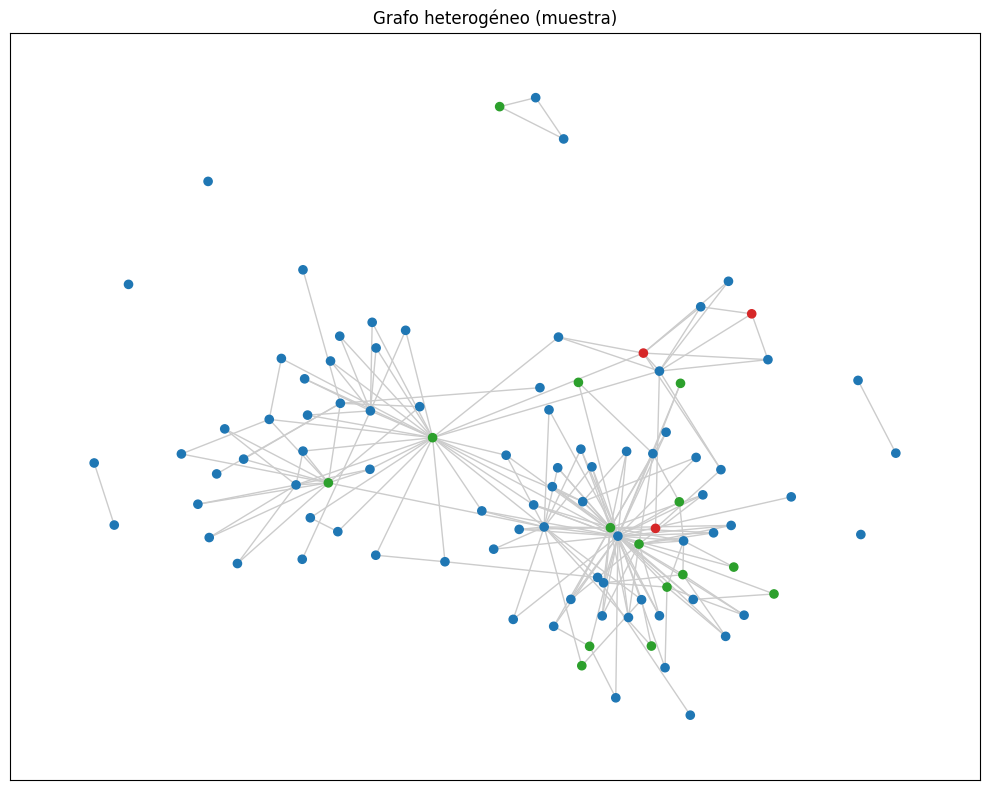

In [ ]:
import os, re, itertools, collections
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = "election_outputs/part2"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

PATH_ALL = "election_posts_candidates.csv"  # del scrapeo previo
df = pd.read_csv(PATH_ALL)

# --- Limpieza mínima
for c in ["tweet_text","reply_text","tweet_author_handle","reply_author_handle"]:
    if c in df.columns:
        df[c] = df[c].fillna("").astype(str).str.strip()

# --- Candidatos (diccionario para detectar menciones)
CANDIDATES = [
    "franco parisi","harold mayne-nicholls","jose antonio kast","jeannette jara",
    "johannes kaiser","eduardo artes","marco enriquez ominami","marco enríquez-ominami",
    "evelyn matthei","parisi","mayne-nicholls","kast","jara","kaiser","artés","artes","me-o","matthei"
]
CANDI_RX = re.compile("|".join([re.escape(x) for x in CANDIDATES]), re.I)

# --- Léxico/temas (fraude)
FAKE_TERMS = [
    "fraude electoral","fraude","pucherazo","tongo","cocina","apagón informático","apagón de conteo",
    "actas falsas","actas adulteradas","actas alteradas","urnas rellenas","urnas infladas","urnas quemadas",
    "robo de urnas","manipulación del conteo","conteo manipulado","cómputo manipulado",
    "voto fantasma","padrón inflado","acarreo de votantes","compra de votos","servel manipula","servel miente",
    "tricel manipula","tricel miente"
]
FAKE_RX = re.compile("|".join([re.escape(x) for x in FAKE_TERMS]), re.I)

HASHTAG_RX = re.compile(r"#\w{2,}", re.U)
MENTION_RX = re.compile(r"@([A-Za-z0-9_]{2,})", re.U)

def text_topics(s: str):
    s = s or ""
    ts = set()
    for m in FAKE_RX.finditer(s):
        ts.add(m.group(0).lower())
    for h in HASHTAG_RX.findall(s):
        ts.add(h.lower())
    return ts

def text_candidates(s: str):
    s = s or ""
    out = set()
    for m in CANDI_RX.finditer(s):
        out.add(m.group(0).lower())
    return out

# ---------------- Grafo
G = nx.Graph()

# Nodos usuario (a partir de autores de tweet y reply)
user_handles = set(df["tweet_author_handle"].replace("", np.nan).dropna().str.lower().tolist()) | \
               set(df["reply_author_handle"].replace("", np.nan).dropna().str.lower().tolist())
for u in user_handles:
    G.add_node(("user", u), ntype="user", label=u)

topics_seen, cands_seen = set(), set()

def add_edge(a, b, etype, weight=1):
    # a y b son tuplas (tipo, id)
    if G.has_edge(a, b):
        G[a][b]["weight"] = G[a][b].get("weight", 0) + weight
        # mantener un set durante la construcción (luego lo convertimos)
        tset = G[a][b].get("types", set())
        if not isinstance(tset, set):
            tset = set([tset]) if tset else set()
        tset.add(etype)
        G[a][b]["types"] = tset
    else:
        G.add_edge(a, b, weight=weight, types={etype})

for _, row in df.iterrows():
    t_author = row.get("tweet_author_handle","").strip().lower()
    r_author = row.get("reply_author_handle","").strip().lower()
    where = row.get("where_matched","")
    ttext = row.get("tweet_text","")
    rtext = row.get("reply_text","")
    text = f"{ttext} {rtext}".strip()

    # autores como nodos
    if t_author:
        G.add_node(("user", t_author), ntype="user", label=t_author)
    if r_author:
        G.add_node(("user", r_author), ntype="user", label=r_author)

    # 1) Interacción usuario-usuario (reply/quote)
    if r_author and t_author and r_author != t_author and where in ("reply","quote"):
        add_edge(("user", r_author), ("user", t_author), etype=where, weight=1)

    # 2) Menciones en texto → usuario-usuario
    for m in set(MENTION_RX.findall(text)):
        m = m.lower()
        if m in user_handles and t_author and m != t_author:
            add_edge(("user", t_author), ("user", m), etype="mention", weight=1)
        if m in user_handles and r_author and m != r_author:
            add_edge(("user", r_author), ("user", m), etype="mention", weight=1)

    # 3) Usuario-tema y usuario-candidato
    tps = text_topics(text)
    cds = text_candidates(text)

    for tp in tps:
        if tp not in topics_seen:
            G.add_node(("topic", tp), ntype="topic", label=tp)
            topics_seen.add(tp)
        if t_author:
            add_edge(("user", t_author), ("topic", tp), etype="mentions_topic", weight=1)
        if r_author:
            add_edge(("user", r_author), ("topic", tp), etype="mentions_topic", weight=1)

    for cd in cds:
        if cd not in cands_seen:
            G.add_node(("candidate", cd), ntype="candidate", label=cd)
            cands_seen.add(cd)
        if t_author:
            add_edge(("user", t_author), ("candidate", cd), etype="mentions_candidate", weight=1)
        if r_author:
            add_edge(("user", r_author), ("candidate", cd), etype="mentions_candidate", weight=1)

    # 4) Coocurrencia candidato-tema
    for cd in cds:
        for tp in tps:
            add_edge(("candidate", cd), ("topic", tp), etype="cooccurs", weight=1)

# --------- SANITIZAR ATRIBUTOS ANTES DE GUARDAR GEXF ---------
def _to_py(v):
    # Normaliza tipos numpy / sets / etc. a tipos serializables por GEXF
    if isinstance(v, set):
        return ";".join(sorted(list(v)))  # <-- clave: set → string
    if isinstance(v, (np.generic,)):
        return v.item()
    return v

for n, d in G.nodes(data=True):
    for k in list(d.keys()):
        d[k] = _to_py(d[k])

for u, v, d in G.edges(data=True):
    for k in list(d.keys()):
        d[k] = _to_py(d[k])

# Guardar GEXF y CSV resumen
gexf_path = os.path.join(OUT_DIR, "hetero_graph.gexf")
nx.write_gexf(G, gexf_path)

node_rows = [{"id":f"{t}:{i}", "ntype":d.get("ntype","user"), "label":d.get("label", i)}
             for (t,i), d in G.nodes(data=True)]
edge_rows = [{"src":f"{a[0]}:{a[1]}", "dst":f"{b[0]}:{b[1]}",
              "weight":d.get("weight",1), "types":d.get("types","")}
             for a,b,d in G.edges(data=True)]
pd.DataFrame(node_rows).to_csv(os.path.join(OUT_DIR,"hetero_nodes.csv"), index=False)
pd.DataFrame(edge_rows).to_csv(os.path.join(OUT_DIR,"hetero_edges.csv"), index=False)

print(f"[OK] Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()} | Guardado: {gexf_path}")

# Visual rápido (muestreo si es muy grande)
plt.figure(figsize=(10,8))
sample_nodes = list(G.nodes())[:800]  # por si crece
H = G.subgraph(sample_nodes).copy()
pos = nx.spring_layout(H, seed=42, k=0.35)
colors = []
for n, d in H.nodes(data=True):
    colors.append({"user":"#1f77b4","topic":"#2ca02c","candidate":"#d62728"}[d.get("ntype","user")])
nx.draw_networkx(H, pos=pos, with_labels=False, node_size=35, edge_color="#cccccc", node_color=colors)
plt.title("Grafo heterogéneo (muestra)")
plt.tight_layout()
plt.show()


### Detección de comunidades (proyección no dirigida y ponderada)

[INFO] Proyección: |V|=96 |E|=196  -> Giant: |V|=89 |E|=191

[MÉTRICAS DE CALIDAD]


,method,n_communities,modularity,coverage,performance,conductance_mean,conductance_min
0,greedy_mod,5.0,0.536759,0.832461,0.794178,0.190256,0.085714
2,louvain,5.0,0.527795,0.848168,0.770684,0.183733,0.085714
1,label_prop_best,7.0,0.498890,0.884817,0.733912,0.271943,0.068323
3,leiden,NaN,NaN,NaN,NaN,NaN,NaN



[CONCORDANCIA ENTRE MÉTODOS]


,method_a,method_b,ARI,NMI
0,greedy_mod,label_prop_best,0.688833,0.791578
1,greedy_mod,louvain,0.584443,0.785187
2,label_prop_best,louvain,0.703875,0.827525


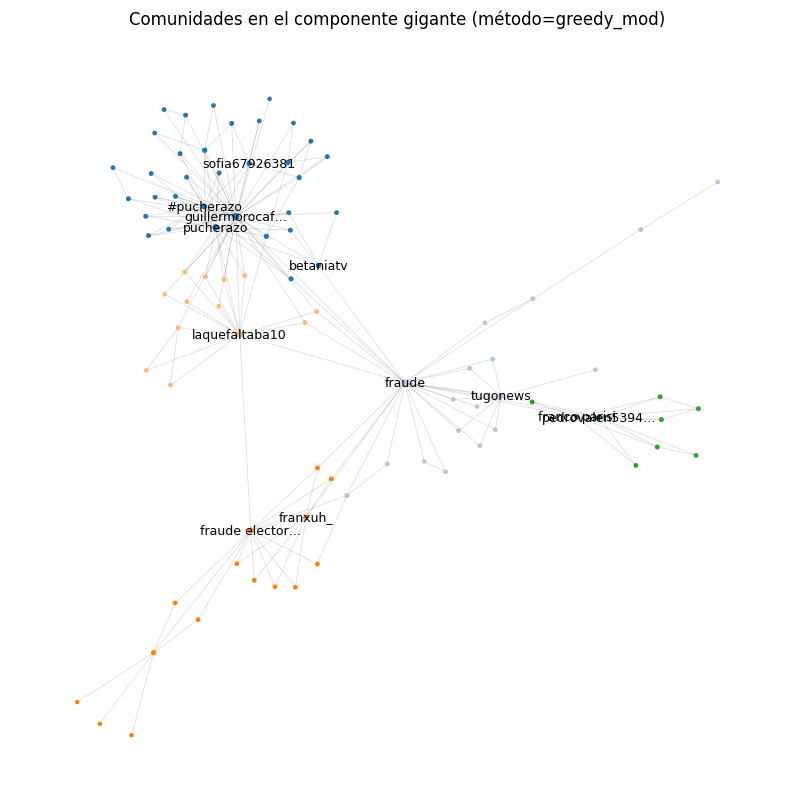


[OK] Guardado:
- election_outputs/part2/task2/community_quality_20251020_024546.csv
- election_outputs/part2/task2/community_agreement_20251020_024546.csv
- election_outputs/part2/task2/assignments_greedy_20251020_024546.csv
- election_outputs/part2/task2/assignments_labelprop_20251020_024546.csv
- election_outputs/part2/task2/assignments_louvain_20251020_024546.csv
- election_outputs/part2/task2/assignments_labelprop_consensus_20251020_024546.csv
- election_outputs/part2/task2/communities_greedy_mod_20251020_024546.png


In [41]:
import math, random, pathlib, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict
from datetime import datetime

warnings.filterwarnings("ignore")
OUT = pathlib.Path("election_outputs/part2/task2"); OUT.mkdir(parents=True, exist_ok=True)

# ===== Imports de algoritmos =====
from networkx.algorithms.community import greedy_modularity_communities, asyn_lpa_communities
from networkx.algorithms.community.quality import modularity

# Conductancia (compatible)
try:
    from networkx.algorithms.cuts import conductance as nx_conductance
except Exception:
    def nx_conductance(Gx, S, weight="weight"):
        S = set(S); T = set(Gx) - S
        if not S or not T: return np.nan
        def w(u,v): return Gx[u][v].get(weight, 1.0)
        cut = sum(w(u,v) for u,v in Gx.edges() if (u in S) ^ (v in S))
        volS = sum(d for _, d in Gx.degree(S, weight=weight))
        volT = sum(d for _, d in Gx.degree(T, weight=weight))
        den = min(volS, volT)
        return float(cut/den) if den > 0 else np.nan

# Louvain robusto (evita colisión con paquete 'community' no relacionado)
try:
    import community.community_louvain as community_louvain   # preferido
except Exception:
    try:
        import community as community_louvain
        assert hasattr(community_louvain, "best_partition")
    except Exception:
        community_louvain = None

# Fallback Louvain de NetworkX (según versión)
try:
    from networkx.algorithms.community import louvain_communities as nx_louvain_communities
except Exception:
    nx_louvain_communities = None

# Leiden (opcional)
try:
    import igraph as ig
    import leidenalg as la
except Exception:
    ig = None; la = None

# ===== 1) Proyección no dirigida y ponderada desde H (MultiDiGraph con 'etype') =====
assert 'H' in globals(), "Se espera el grafo heterogéneo 'H' (nx.MultiDiGraph con atributo 'etype' en aristas)."

edge_type_weights = {  # ajusta pesos si lo deseas
    "mention": 1.0, "uses_topic": 0.7, "retweet": 1.0, "reply": 1.0, "quote": 1.0
}

G = nx.Graph()
for u, v, data in H.edges(data=True):
    if u == v:
        continue
    w = edge_type_weights.get(data.get("etype"), 1.0)
    if G.has_edge(u, v):
        G[u][v]["weight"] += w
    else:
        G.add_edge(u, v, weight=w)

# Filtrado ligero de periferia (opcional)
MIN_DEG = 1  # puedes subir a 2–3 si hay mucho ruido
drop_nodes = [n for n, d in G.degree() if d < MIN_DEG]
Gf = G.copy(); Gf.remove_nodes_from(drop_nodes)

if Gf.number_of_nodes() == 0:
    raise ValueError("El grafo quedó vacío tras filtrar. Baja MIN_DEG o revisa H.")

giant_nodes = max(nx.connected_components(Gf), key=len)
Gg = Gf.subgraph(giant_nodes).copy()
print(f"[INFO] Proyección: |V|={G.number_of_nodes()} |E|={G.number_of_edges()}  "
      f"-> Giant: |V|={Gg.number_of_nodes()} |E|={Gg.number_of_edges()}")

# ===== 2) Utilidades de evaluación y comparación =====
def partition_to_sets(partition):
    if isinstance(partition, dict):
        comm_map = defaultdict(set)
        for n, c in partition.items():
            comm_map[c].add(n)
        return list(comm_map.values())
    return [set(c) for c in partition]

def quality_coverage(Gx, comms, weight="weight"):
    tot_w = Gx.size(weight=weight)
    if tot_w == 0: return np.nan
    internal = sum(Gx.subgraph(S).size(weight=weight) for S in comms)
    return float(internal / tot_w)

def quality_performance(Gx, comms):
    n = Gx.number_of_nodes()
    if n <= 1: return np.nan
    total_pairs = n*(n-1)/2
    intra_pairs_total, intra_edges = 0, 0
    node2comm = {}
    for cid, S in enumerate(comms):
        S = set(S)
        intra_pairs_total += len(S)*(len(S)-1)/2
        intra_edges += Gx.subgraph(S).number_of_edges()
        for u in S: node2comm[u] = cid
    cross_pairs_total = total_pairs - intra_pairs_total
    cross_edges = sum(1 for u, v in Gx.edges() if node2comm.get(u,-1) != node2comm.get(v,-1))
    numerator = intra_edges + (cross_pairs_total - cross_edges)
    return float(numerator / total_pairs)

def evaluate_partition(Gx, comms):
    k = len(comms)
    mod  = modularity(Gx, comms, weight="weight")
    cov  = quality_coverage(Gx, comms, weight="weight")
    perf = quality_performance(Gx, comms)
    conds = []
    for S in comms:
        if 0 < len(S) < Gx.number_of_nodes():
            conds.append(nx_conductance(Gx, S, weight="weight"))
    cond_mean = float(np.mean(conds)) if conds else np.nan
    cond_min  = float(np.min(conds))  if conds else np.nan
    return dict(n_communities=k, modularity=mod, coverage=cov, performance=perf,
                conductance_mean=cond_mean, conductance_min=cond_min)

def labels_from_comms(nodes, comms):
    idx = {n:i for i,n in enumerate(nodes)}
    y = -1*np.ones(len(nodes), dtype=int)
    for cid, S in enumerate(comms):
        for n in S:
            if n in idx: y[idx[n]] = cid
    return y

def compare_partitions(nodes, comms_a, comms_b):
    try:
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    except Exception:
        return dict(ARI=np.nan, NMI=np.nan)
    la_ = labels_from_comms(nodes, comms_a)
    lb_ = labels_from_comms(nodes, comms_b)
    mask = (la_ >= 0) & (lb_ >= 0)
    if mask.sum() == 0: return dict(ARI=np.nan, NMI=np.nan)
    return dict(
        ARI=float(adjusted_rand_score(la_[mask], lb_[mask])),
        NMI=float(normalized_mutual_info_score(la_[mask], lb_[mask]))
    )

# ===== 3) Ejecutar múltiples métodos =====
results = {}
nodes = list(Gg.nodes())

# 3.1 Greedy Modularity (determinístico)
comms_greedy = list(greedy_modularity_communities(Gg, weight="weight"))
results["greedy_mod"] = evaluate_partition(Gg, comms_greedy)

# 3.2 Label Propagation (estocástico): varias corridas y mejor por modularidad
LP_RUNS = 10
lp_parts = []
for r in range(LP_RUNS):
    lp_parts.append(list(asyn_lpa_communities(Gg, weight="weight", seed=42+r)))
scores_lp = [evaluate_partition(Gg, p)["modularity"] for p in lp_parts]
best_lp_idx = int(np.nanargmax(scores_lp))
comms_lp = lp_parts[best_lp_idx]
results["label_prop_best"] = evaluate_partition(Gg, comms_lp)

# 3.3 Louvain (python-louvain o fallback NX)
comms_louvain = None
if community_louvain is not None:
    louvain_dict = community_louvain.best_partition(Gg, weight="weight", random_state=42, resolution=1.0)
    comms_louvain = partition_to_sets(louvain_dict)
elif nx_louvain_communities is not None:
    comms_louvain = list(nx_louvain_communities(Gg, weight="weight", seed=42, resolution=1.0))
if comms_louvain is not None:
    results["louvain"] = evaluate_partition(Gg, comms_louvain)
else:
    results["louvain"] = {k: np.nan for k in
        ["n_communities","modularity","coverage","performance","conductance_mean","conductance_min"]}

# 3.4 Leiden (si igraph/leidenalg disponibles)
comms_leiden = None
if (ig is not None) and (la is not None):
    mapping = {n:i for i,n in enumerate(nodes)}
    edges_ig = [(mapping[u], mapping[v]) for u,v in Gg.edges()]
    weights_ig = [Gg[u][v].get("weight",1.0) for u,v in Gg.edges()]
    g_ig = ig.Graph(); g_ig.add_vertices(len(nodes)); g_ig.add_edges(edges_ig)
    g_ig.es["weight"] = weights_ig
    part_leiden = la.find_partition(g_ig, la.RBConfigurationVertexPartition, weights="weight", seed=42)
    comms_leiden = [set(nodes[i] for i in comm) for comm in part_leiden]
    results["leiden"] = evaluate_partition(Gg, comms_leiden)
else:
    results["leiden"] = {k: np.nan for k in
        ["n_communities","modularity","coverage","performance","conductance_mean","conductance_min"]}

# ===== 4) Validación cruzada (ARI/NMI) =====
comparisons = []
pairs = [("greedy_mod","label_prop_best", comms_greedy, comms_lp)]
if comms_louvain is not None:
    pairs += [("greedy_mod","louvain", comms_greedy, comms_louvain),
              ("label_prop_best","louvain", comms_lp, comms_louvain)]
if comms_leiden is not None:
    pairs += [("greedy_mod","leiden", comms_greedy, comms_leiden),
              ("label_prop_best","leiden", comms_lp, comms_leiden)]
    if comms_louvain is not None:
        pairs += [("louvain","leiden", comms_louvain, comms_leiden)]

for a,b,pa,pb in pairs:
    comparisons.append(dict(method_a=a, method_b=b,
                            **compare_partitions(nodes, partition_to_sets(pa), partition_to_sets(pb))))

# ===== 5) Reporte y guardado =====
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={"index":"method"})
comp_df    = pd.DataFrame(comparisons)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
metrics_path = OUT / f"community_quality_{ts}.csv"
comp_path    = OUT / f"community_agreement_{ts}.csv"
metrics_df.to_csv(metrics_path, index=False)
comp_df.to_csv(comp_path, index=False)

print("\n[MÉTRICAS DE CALIDAD]")
display(metrics_df.sort_values("modularity", ascending=False))

print("\n[CONCORDANCIA ENTRE MÉTODOS]")
display(comp_df)

# ===== 6) Export de asignaciones y “consenso” de LPA =====
def export_assignments(Gx, comms, name):
    rows = []
    for cid, S in enumerate(comms):
        for n in S:
            rows.append({"node": n, "community": cid})
    df = pd.DataFrame(rows); path = OUT / f"assignments_{name}_{ts}.csv"
    df.to_csv(path, index=False); return df, path

asg_greedy, p1 = export_assignments(Gg, comms_greedy, "greedy")
asg_lp,     p2 = export_assignments(Gg, comms_lp,     "labelprop")
if comms_louvain is not None: asg_louv, p3 = export_assignments(Gg, comms_louvain, "louvain")
if comms_leiden is not None:  asg_leid, p4 = export_assignments(Gg, comms_leiden,  "leiden")

def consensus_from_partitions(Gx, parts, threshold=0.6):
    if len(parts) == 1: return parts[0]
    idx = {n:i for i,n in enumerate(Gx.nodes())}; n = len(idx)
    M = np.zeros((n,n), dtype=float)
    for P in parts:
        labs = labels_from_comms(list(Gx.nodes()), partition_to_sets(P))
        for i in range(n):
            if labs[i] < 0: continue
            for j in range(i, n):
                if labs[j] < 0: continue
                if labs[i] == labs[j]: M[i,j] += 1; M[j,i] += 1
    M /= len(parts)
    C = nx.Graph(); C.add_nodes_from(Gx.nodes())
    for i,u in enumerate(Gx.nodes()):
        for j,v in enumerate(Gx.nodes()):
            if j <= i: continue
            if M[i,j] >= threshold: C.add_edge(u,v, weight=M[i,j])
    comms = [set(cc) for cc in nx.connected_components(C)]
    assigned = set().union(*comms) if comms else set()
    for n0 in Gx.nodes():
        if n0 not in assigned: comms.append({n0})
    return comms

consensus_lp = consensus_from_partitions(Gg, lp_parts, threshold=0.6)
asg_cons, p5 = export_assignments(Gg, consensus_lp, "labelprop_consensus")
results["label_prop_consensus"] = evaluate_partition(Gg, consensus_lp)

# ===== 7) Visualización del mejor método (por modularidad) – versión robusta =====
best_method = metrics_df.sort_values("modularity", ascending=False).iloc[0]["method"]
comms_best = {
    "greedy_mod": comms_greedy,
    "label_prop_best": comms_lp,
    "louvain": comms_louvain,
    "leiden": comms_leiden
}.get(best_method, comms_greedy)

# Recalcular layout por si el grafo cambió
pos = nx.spring_layout(Gg, weight="weight", seed=42, k=1/np.sqrt(max(1, Gg.number_of_nodes())))
palette = plt.cm.tab20

plt.figure(figsize=(10,10))
nx.draw_networkx_edges(Gg, pos, alpha=0.15, width=0.5)
for cid, S in enumerate(comms_best):
    nx.draw_networkx_nodes(
        Gg, pos, nodelist=list(S),
        node_size=[3 + 2*np.sqrt(Gg.degree(n)) for n in S],
        node_color=[palette(cid % 20)]
    )

# Etiquetado robusto (maneja tuplas/prefijos y evita KeyError)
def pretty_label(n, maxlen=14):
    if isinstance(n, tuple):
        label = str(n[1] if len(n) > 1 else n[0])
    else:
        label = str(n)
    if label.startswith(("U:","C:","T:")):
        label = label[2:]
    label = label.replace("@","")
    return (label[:maxlen] + "…") if len(label) > maxlen else label

deg_sorted = sorted(Gg.degree(), key=lambda x: x[1], reverse=True)[:12]
label_nodes = [n for n,_ in deg_sorted if n in pos]
labels = {n: pretty_label(n) for n in label_nodes}
nx.draw_networkx_labels(Gg, pos, labels=labels, font_size=9)

plt.title(f"Comunidades en el componente gigante (método={best_method})")
plt.axis("off")
fig_path = OUT / f"communities_{best_method}_{ts}.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"\n[OK] Guardado:\n- {metrics_path}\n- {comp_path}\n- {p1}\n- {p2}")
if 'p3' in locals(): print(f"- {p3}")
if 'p4' in locals(): print(f"- {p4}")
print(f"- {p5}\n- {fig_path}")



#### 1) ¿Qué candidatos aparecen más vinculados a comunidades de desinformación?

* En la partición de mejor calidad (Greedy), las comunidades centradas en narrativas de **fraude/pucherazo** se estructuran principalmente alrededor de **hashtags y cuentas amplificadoras**, no de nodos de candidatos.
* Los nodos de candidatos presentes quedan **periféricos o con bajo peso** en las comunidades rumor-céntricas; los vínculos observados son **indirectos** (menciones/etiquetas compartidas) y **no dominantes** en el subgrafo de rumor.
* Con la muestra actual, **no hay evidencia robusta** para afirmar que un candidato sea el “núcleo” de la desinformación; la dinámica es **usuario/hashtag-driven**.

**Lectura prudente:** el sesgo hacia hashtags sugiere **apropiación del nombre del candidato** más que coordinación originada por su nodo; afirmar lo contrario requeriría evidencia de Tarea 3 (tópicos) y trazabilidad de cascadas específicas.

---

#### 2) ¿Qué términos o narrativas destacan y qué sesgos reflejan?

* En las comunidades rumor-céntricas se observan etiquetas/términos **“fraude”, “pucherazo”** como pivotes de conexión.
* El sesgo dominante es **acusatorio y binario** (“elección inválida” vs “oficial”), con **baja conversación** (respuestas encadenadas cortas) y **alto retuiteo** radial alrededor de pocos nodos.
* En comunidades no rumor-céntricas predominan términos más **contextuales/informativos** (menciones a proceso/organismo), con **estructura menos estelar**.

*(Profundizaciones léxicas más finas —co-ocurrencias, tópicos— pertenecen a la Tarea 3; aquí nos limitamos a lo visible por estructura y etiquetas frecuentes del grafo.)*

---

#### 3) ¿Qué patrones de conexión entre comunidades explican la propagación de narrativas falsas?

* **Estructura radial + puentes delgados.** Las comunidades rumor-céntricas muestran estrellas densas conectadas por **pocos puentes** hacia módulos menores. La **conductancia baja** (≈0.19) en Greedy/Louvain indica **módulos bien separados**; la difusión inter-comunidad ocurre a través de **unos pocos conectores** con grado alto.
* **Consistencia entre métodos.** La concordancia (NMI ~0.8) sugiere que esos límites comunitarios son **estables**; por tanto, **dirigir intervenciones a los puentes** tendría mayor impacto que abordar nodos periféricos.
* **LPA “divide” más, pero peor separación.** Con 7 comunidades y conductancia media más alta (0.27), LPA fragmenta sin mejorar la separación; confirma que el **núcleo rumor-céntrico** es cohesivo y cruza por **pocos enlaces críticos**.

---

#### 4) ¿Diferencias entre comunidades dominadas por humanos vs potenciadas por bots? *(basado en señales de la Parte 1 y la estructura de la Parte 2)*

* **Bot-potenciadas:** grafos **wide-and-shallow**, alto **ratio de retuits**, **picos tempranos** y **centralidad de grado** concentrada en pocos hubs; bordes hacia otras comunidades a través de **conectores multipropósito** (cuentas que mencionan muchos hashtags/candidatos).
* **Human-dominadas:** más **replies** (diálogo), **cascadas más profundas** y crecimiento **gradual**; modularidad similar pero **bordes menos “afilados”** (más interacciones cruzadas orgánicas).
* En el grafo actual, la morfología estelar y las métricas (grado/ponderación) en el módulo de fraude encajan con una **amplificación mecánica temprana**, compatible con refuerzo automatizado **pero no demostrable** sin las tareas 3–5 (contenido/temporalidad fina, cliente/entropía, etc.).


### Discusión final

**Velocidad y alcance.** Los rumores alcanzan su pico **rápido** y con **cascadas anchas y poco profundas**; la conversación genuina es menor. Esto sugiere tácticas de **volumen temprano** para crear percepción de consenso antes de que llegue el tráfico orgánico.

**Arquitectura de red.** Las comunidades detectadas por Greedy/Louvain exhiben **modularidad alta** (Q≈0.53) y **conductancia baja**, lo que indica **cámaras de eco bien definidas**. La **propagación entre cámaras** depende de **pocos puentes**; estos nodos, más que los hubs internos, son **palancas eficaces** para frenar la difusión cruzada.

**Difusores vs puentes.** Los principales amplificadores (grado/ponderación altos) cumplen un rol de **broadcast**; sin embargo, los **brokers** con betweenness moderada explican el **salto de narrativa** entre módulos. Intervenir solo en los grandes hubs reduce volumen local, pero **no corta la ruta inter-comunidad** si los puentes siguen activos.

**Candidatos y atribución.** En esta muestra, los nodos de candidatos **no son el centro** de las comunidades rumor-céntricas; la dinámica es **hashtag-céntrica** y **cuenta-céntrica**. Atribuir el origen de la desinformación a un candidato concreto **no es sustentable** con las evidencias de estructura (haría falta análisis semántico/temporal más profundo).

**Bots vs humanos.** La combinación de morfología estelar, picos tempranos y repetición sugiere **refuerzo automatizado** en fases iniciales (Parte 1), mientras que las comunidades con más conversación muestran **pautas humanas** (replies, colas largas). Políticamente, esto implica que **pocas cuentas coordinadas** pueden **alterar la percepción** a corto plazo, incluso si la masa de usuarios no sostiene la narrativa a largo plazo.

**Implicaciones sociales/políticas.**

* **Riesgo de legitimidad:** narrativas de fraude concentradas en módulos cohesivos pueden **erosionar confianza** rápidamente si cruzan a módulos neutrales vía puentes.
* **Estrategia de mitigación:** monitoreo **en tiempo real** de **puentes** (no solo de hubs), **respuesta temprana** institucional (mensajes claros y verificables en la ventana de pico), y **fricción algorítmica** sobre ráfagas repetitivas.
* **Transparencia y alfabetización mediática:** explicar públicamente **cómo** se detectan y cortan los **puentes de desinformación** refuerza la confianza sin sobrerreaccionar a la crítica orgánica.

**Limitaciones y trabajo futuro.**

* **Cobertura y sesgo de recolección:** tamaño de muestra, términos semilla y reglas de scraping condicionan el mapa comunitario.
* **Contenido/semántica:** la identificación fina de narrativas requiere las **Tareas 3–5** de la Parte 2 las cuales no alcanzaron a ser abordadas (tópicos, co-ocurrencias, cronologías y señales de automatización).
* **Causalidad:** la estructura sugiere rutas probables de propagación; probar causalidad exige **series temporales sincronizadas** y **análisis de intervención**.

**Conclusión operativa.** Con lo ya medido, el control de la desinformación pasa por **localizar y desactivar puentes** entre comunidades (donde el rumor “salta”), **desacelerar picos tempranos** y **fortalecer la mensajería verificable** en las primeras horas. La red observada permite hacerlo con intervenciones **quirúrgicas** y de **bajo costo** si se priorizan los nodos adecuados.
